# Per-person leave-one-trial-out runs

For **each participant**, run *full* leave-one-trial-out cross-validation: every
trial is held out once as the test set while the model trains on all of that
participant's remaining trials. The held-out predictions are pooled into one
result per participant, so `accuracy` is the participant's leave-one-out
accuracy.

Feature handling is intentionally identical to the regular
`run_full_features_correctness_bundle` pipeline:
- the feature table is the **cached** `READY_ALL_FEATURES_PATH`
  (`load_all_features()`), the same table the bundle uses, and
- the feature set here is pinned to **`SELECT_1_COLS + LAST_CONFIRM_COMPACT`**
  (the "selection" set plus the compact last-label-before-confirm features),
  passed through exactly as `feature_cols=` in a bundle run.

The model (`TrialLevelLogRegModel`) is fit / predicted / scored through the same
prepared-split machinery, and per-participant coefficients come from a single
full-data fit on that participant's trials (the pipeline's
coefficients-from-a-full-fit convention).

All the analysis lives in
`src/predictive_modeling/answer_correctness/person_variance/` — this notebook
only calls it and displays the results. Every plotting function takes
`save=True, paper_dirs=PAPER_DIRS` (plus `rel_dir` / `filename`) to write the
figure out; they default to `save=False`.

In [1]:
from pathlib import Path
import sys

# Make `src` and the repo root importable regardless of where the kernel started.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
for _p in (PROJECT_ROOT, PROJECT_ROOT / "src"):
    _p = str(_p)
    if _p not in sys.path:
        sys.path.insert(0, _p)

import predictive_modeling.answer_correctness.feature_groups as FG
from predictive_modeling.answer_correctness.model_data import (
    load_all_features,
    save_all_features,
)
from predictive_modeling.answer_correctness.person_variance import (
    accuracy_characterization as AC,
    coef_consistency as CC,
    loo_runs,
    mistake_types as MT,
    person_accuracy as PA,
    univariate_consistency as UC,
)

# The pinned feature set for this notebook. Swap in any other `FG.*` group or
# list, and give it a new tag -- the tag keys the results cache and names any
# saved figure.
FEATURE_COLS = loo_runs.DEFAULT_FEATURE_COLS
FEATURE_SET_TAG = loo_runs.DEFAULT_FEATURE_SET_TAG
PAPER_DIRS = loo_runs.PAPER_DIRS

## Load the (cached) feature table

Prefer the cached full-feature table — the exact same table
`run_full_features_correctness_bundle` uses. If it is stale, rebuild it with:

```python
save_all_features(pd.read_csv(ALL_PARTICIPANTS_PROCESSED_PATH))
```

In [2]:
trial_df = load_all_features()
print(f"{trial_df.shape[0]} trials x {trial_df.shape[1]} cols")
trial_df.head()

19436 trials x 217 cols


,participant_id,TRIAL_INDEX,text_id_with_q,is_correct,area_dwell_proportion__answer_A,area_dwell_proportion__answer_B,area_dwell_proportion__answer_C,area_dwell_proportion__answer_D,area_dwell_proportion__question,first_encounter_avg_pupil_size_z__answer_A,...,TimeSinceOffset_pure_distance_furthest,TimeSinceOffset_pure_distance_closest,TimeSinceOffset_normalized_correct,TimeSinceOffset_normalized_wrong_mean,TimeSinceOffset_normalized_contrast,TimeSinceOffset_normalized_distance_furthest,TimeSinceOffset_normalized_distance_closest,ANSWER_PRESS_NUMBER,total_answering_RT,total_answering_RT_normalized
0,l42_2070,4,3_6_Ele_1_2,1,0.319310,0.213167,0.181306,0.257173,0.029044,0.798335,...,1734.0,251.0,593.000000,602.857143,-9.857143,163.000000,48.857143,1,7330,222.121212
1,l42_2070,5,3_6_Adv_2_2,1,0.244538,0.469212,0.170161,0.116089,0.000000,0.086368,...,1110.0,23.0,106.083333,261.925926,-155.842593,158.694444,153.116667,1,5650,141.250000
2,l42_2070,6,3_6_Ele_3_0,1,0.388110,0.148282,0.349458,0.079114,0.035036,-0.436190,...,2750.0,1584.0,324.500000,277.523810,46.976190,269.500000,179.928571,1,5562,135.658537
3,l42_2070,7,3_6_Adv_4_1,1,0.501591,0.178867,0.126353,0.147995,0.045194,0.590876,...,3599.0,1576.0,404.900000,219.950000,184.950000,359.900000,89.700000,1,4762,136.057143
4,l42_2070,8,3_6_Ele_5_0,1,0.241206,0.370537,0.153399,0.177466,0.057392,-1.167965,...,1748.0,287.0,123.000000,211.171296,-88.171296,264.625000,59.222222,1,4884,103.914894


## Run full leave-one-trial-out per person

The run is cached under `PER_PERSON_LOO_RESULTS_DIR`, keyed by
`FEATURE_SET_TAG`, so re-running the notebook reloads it instead of refitting.
Pass `force_recompute=True` to re-run anyway.

In [3]:
results_by_pid = loo_runs.run_or_load_per_person_loo(
    trial_df,
    feature_cols=FEATURE_COLS,
    feature_set_tag=FEATURE_SET_TAG,
    force_recompute=False,
)

Using 12 features:
  - area_dwell_proportion__correct
  - area_dwell_proportion__question
  - skip_rate__correct
  - has_xyx
  - ANSWER_PRESS_NUMBER
  - num_label_visits__correct
  - num_label_visits__contrast
  - mean_fixations_count__question
  - mean_fixations_count__wrong_mean
  - mean_max_fix_pupil_size_z__correct
  - last_before_confirm_correct
  - last_before_confirm_question

Loaded 356 participants from cache: E:\Technion\QA PROJECT\programming\QA_eyetracking_workspace\reports\report_data\per_person_corr_loo_results\results_by_pid__select_1_plus_last_confirm_compact.pkl


## Per-person accuracy summary

In [4]:
summary_df = PA.per_person_summary(results_by_pid)
display(summary_df)

Mean per-person accuracy:           0.8334
Mean per-person balanced accuracy:  0.7444


,participant_id,n_trials,n_correct_trials,n_wrong_trials,accuracy,balanced_accuracy
0,l9_38,54,49,5,1.000000,1.000000
1,l35_264,54,50,4,1.000000,1.000000
2,l9_201,54,48,6,1.000000,1.000000
3,l37_401,54,47,7,0.981481,0.989362
4,l53_478,54,46,8,0.981481,0.989130
...,...,...,...,...,...,...
351,l52_428,53,53,0,0.962264,NaN
352,l6_83,53,53,0,1.000000,NaN
353,l59_293,53,53,0,0.792453,NaN
354,l59_504,53,53,0,0.962264,NaN


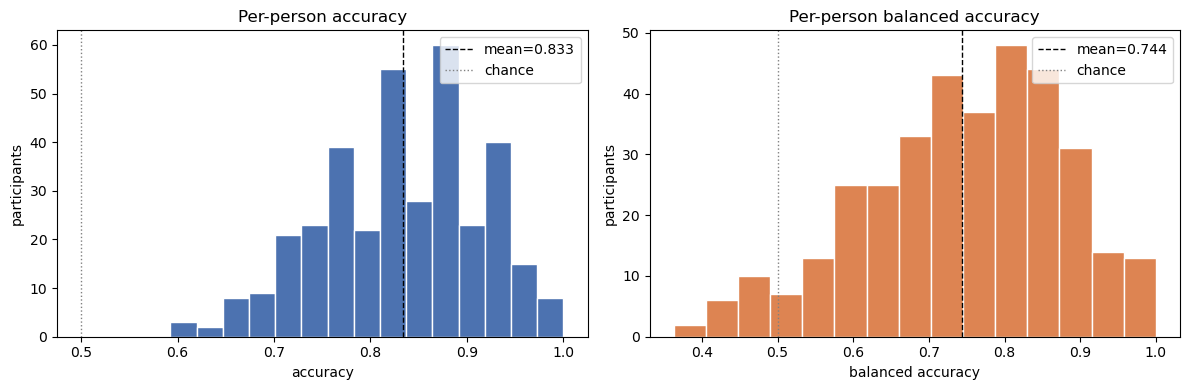

In [5]:
fig_acc, _ = PA.plot_per_person_accuracy_hist(summary_df)

## Per-person coefficients

Each participant's `coef_summary` comes from a single logistic-regression fit on
all of that participant's trials. The helpers below re-shape those into the
nested `{pid: {model_name: result}}` form the existing per-participant
coefficient/clustering utilities expect, so those downstream tools work
unchanged.

,feature,count,n_pos,n_neg,n_zero,total_occ,prop,sign_varies,majority_sign,minority_count
5,last_before_confirm_question,15,11,4,0,15,0.042135,True,1,4
0,ANSWER_PRESS_NUMBER,35,12,23,0,35,0.098315,True,-1,12
2,area_dwell_proportion__question,44,33,11,0,44,0.123596,True,1,11
6,mean_fixations_count__question,50,13,37,0,50,0.140449,True,-1,13
8,mean_max_fix_pupil_size_z__correct,51,12,39,0,51,0.143258,True,-1,12
10,num_label_visits__correct,53,19,34,0,53,0.148876,True,-1,19
3,has_xyx,56,13,43,0,56,0.157303,True,-1,13
11,skip_rate__correct,66,5,61,0,66,0.185393,True,-1,5
9,num_label_visits__contrast,109,105,4,0,109,0.306180,True,1,4
7,mean_fixations_count__wrong_mean,149,1,148,0,149,0.418539,True,-1,1


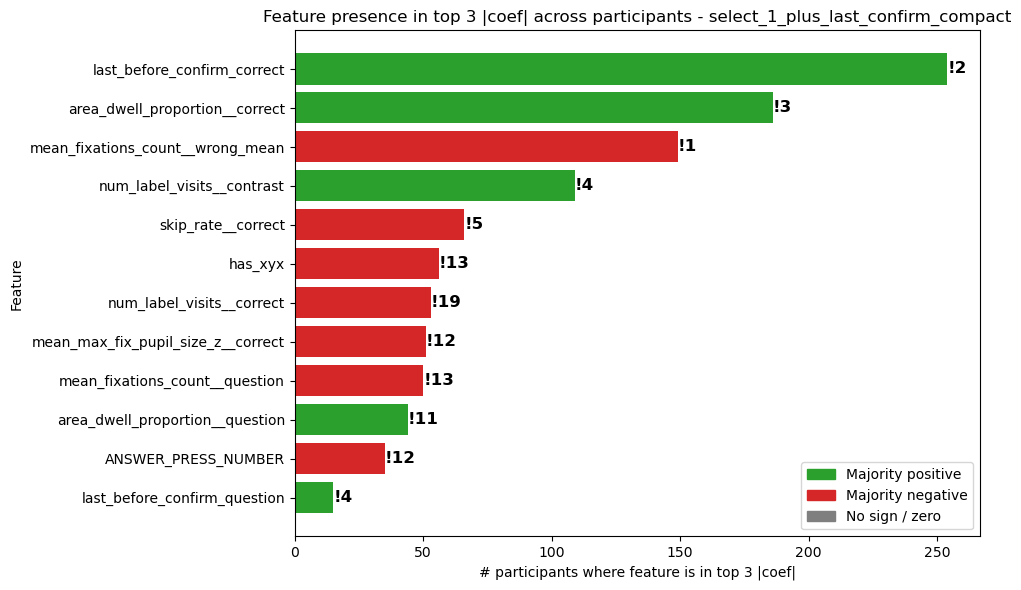

In [6]:
# Small curated set (12 features): show the top-3 |coef| per participant so the
# frequency chart reflects more than a single dominant feature.
fig_freq, freq_df, _ = CC.plot_feature_presence_across_participants(
    results_by_pid,
    feature_set_tag=FEATURE_SET_TAG,
    top_k_within_participant=3,
)
freq_df

,feature,count_participants,mean_rank,median_rank,std_rank,min_rank,max_rank
4,last_before_confirm_correct,356,3.092697,2.0,2.971196,1.0,12.0
1,area_dwell_proportion__correct,356,4.441011,3.0,3.231779,1.0,12.0
7,mean_fixations_count__wrong_mean,356,5.230337,5.0,3.241940,1.0,12.0
9,num_label_visits__contrast,356,5.755618,5.0,3.261270,1.0,12.0
11,skip_rate__correct,356,6.398876,6.0,2.866690,1.0,12.0
3,has_xyx,356,6.915730,7.0,2.966229,1.0,12.0
2,area_dwell_proportion__question,356,7.050562,7.0,2.883215,1.0,12.0
8,mean_max_fix_pupil_size_z__correct,356,7.087079,7.0,3.137372,1.0,12.0
6,mean_fixations_count__question,356,7.117978,7.0,2.898783,1.0,12.0
10,num_label_visits__correct,356,7.162921,8.0,3.028759,1.0,12.0


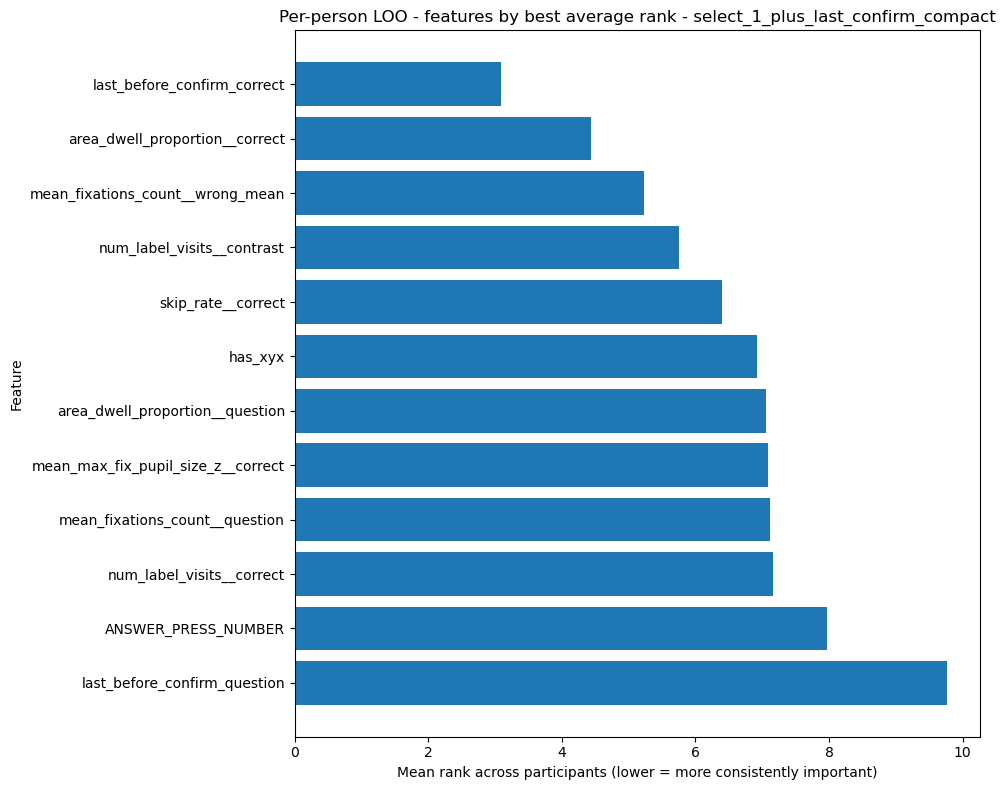

In [7]:
fig_rank, avg_rank_df, _ = CC.plot_feature_avg_rank_across_participants(
    results_by_pid,
    feature_set_tag=FEATURE_SET_TAG,
)
avg_rank_df

## Mean coefficient across participants

Because the feature set is small and fixed, we can average each feature's
coefficient directly across all participants' full-fit `coef_summary` tables.
The bars are the mean log-odds coefficient; the whiskers span
mean +/- 1 std across participants (a quick read on how stable each effect is
from person to person).

,feature,coef,std,n_participants,abs_coef,ci_low,ci_high
0,last_before_confirm_correct,1.077821,0.622483,356,1.077821,0.455338,1.700303
1,area_dwell_proportion__correct,0.741291,0.577472,356,0.741291,0.163819,1.318762
2,mean_fixations_count__wrong_mean,-0.625621,0.490690,356,0.625621,-1.116310,-0.134931
3,num_label_visits__contrast,0.506184,0.501395,356,0.506184,0.004788,1.007579
4,skip_rate__correct,-0.310889,0.526525,356,0.310889,-0.837414,0.215636
5,area_dwell_proportion__question,0.203558,0.496210,356,0.203558,-0.292652,0.699768
6,mean_max_fix_pupil_size_z__correct,-0.159107,0.549419,356,0.159107,-0.708525,0.390312
7,has_xyx,-0.149721,0.555142,356,0.149721,-0.704863,0.405421
8,mean_fixations_count__question,-0.114944,0.509808,356,0.114944,-0.624752,0.394864
9,last_before_confirm_question,0.106958,0.303609,356,0.106958,-0.196651,0.410567


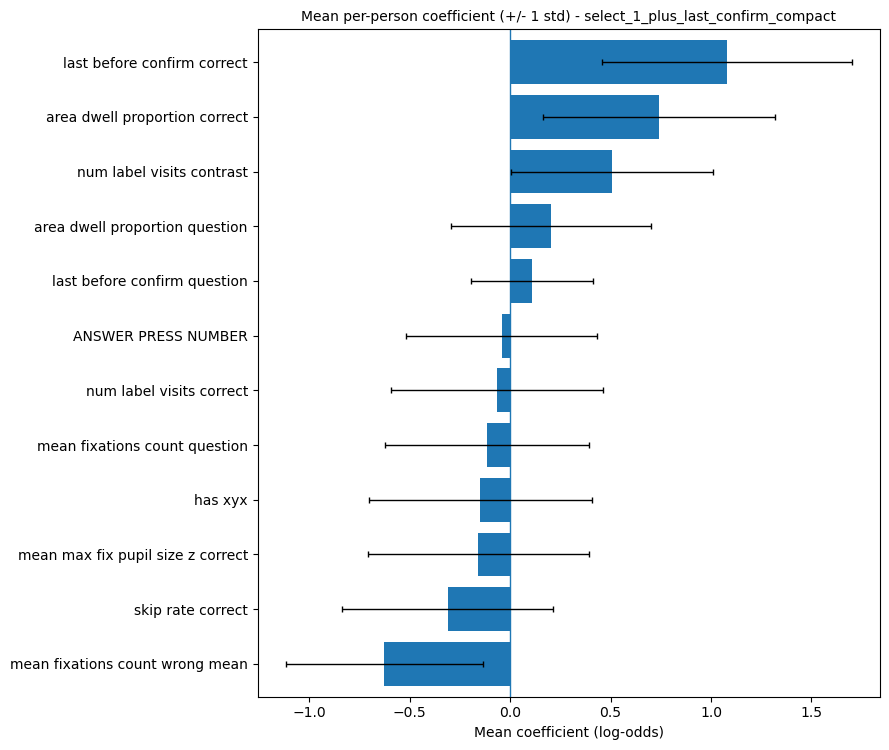

In [8]:
mean_coef_df = CC.mean_coef_across_participants(results_by_pid)
display(mean_coef_df)

fig_mean_coef, _, _ = CC.plot_mean_coef_across_participants(
    mean_coef_df, feature_set_tag=FEATURE_SET_TAG
)

## Coefficient consistency across participants

Which of the 12 features mean the *same thing* for everyone, and which flip from
person to person? Two aligned views, sorted most- to least-consistent:

- **Direction split** (left) — for each feature, the share of participants whose
  per-person coefficient is negative / ≈zero / positive. A near-solid bar =
  everyone agrees on direction; a two-colour split = the effect **flips sign**
  between people; a large grey band = the feature is **inactive** for many people
  (coefficient ≈ 0, e.g. it never fires in their trials — as with
  `last_before_confirm_question`, ~0 for half). The `%` on the right is the
  dominant-direction share.
- **Magnitude spread** (right) — each participant's coefficient divided by that
  feature's own `mean|coef|`, so magnitudes are comparable across features while
  sign and zero-crossing are preserved. Tight around `±1` = consistent magnitude;
  a cloud straddling `0` = the effect varies person to person. The single-number
  version is `dispersion_index = SD / mean|coef|` (0 = identical, >1 = spread
  exceeds the typical size).

**Caveat:** each `β_p` is fit on ~54 trials, so part of the spread is estimation
noise, not true between-person variation — read this as an *upper bound* on
inconsistency. This is a descriptive consistency read, not a significance test.

,feature,n_participants,mean,share_negative,share_zero,share_positive,dominant_share,dispersion_index
0,last_before_confirm_correct,356,1.078,0.070,0.000,0.930,0.930,0.556
1,area_dwell_proportion__correct,356,0.741,0.098,0.000,0.902,0.902,0.711
2,mean_fixations_count__wrong_mean,356,-0.626,0.896,0.000,0.104,0.896,0.728
3,num_label_visits__contrast,356,0.506,0.160,0.000,0.840,0.840,0.842
4,skip_rate__correct,356,-0.311,0.711,0.000,0.289,0.711,1.047
5,area_dwell_proportion__question,356,0.204,0.334,0.000,0.666,0.666,1.149
6,mean_max_fix_pupil_size_z__correct,356,-0.159,0.621,0.000,0.379,0.621,1.238
7,mean_fixations_count__question,356,-0.115,0.612,0.000,0.388,0.612,1.216
8,has_xyx,356,-0.150,0.593,0.000,0.407,0.593,1.200
9,num_label_visits__correct,356,-0.065,0.539,0.000,0.461,0.539,1.245


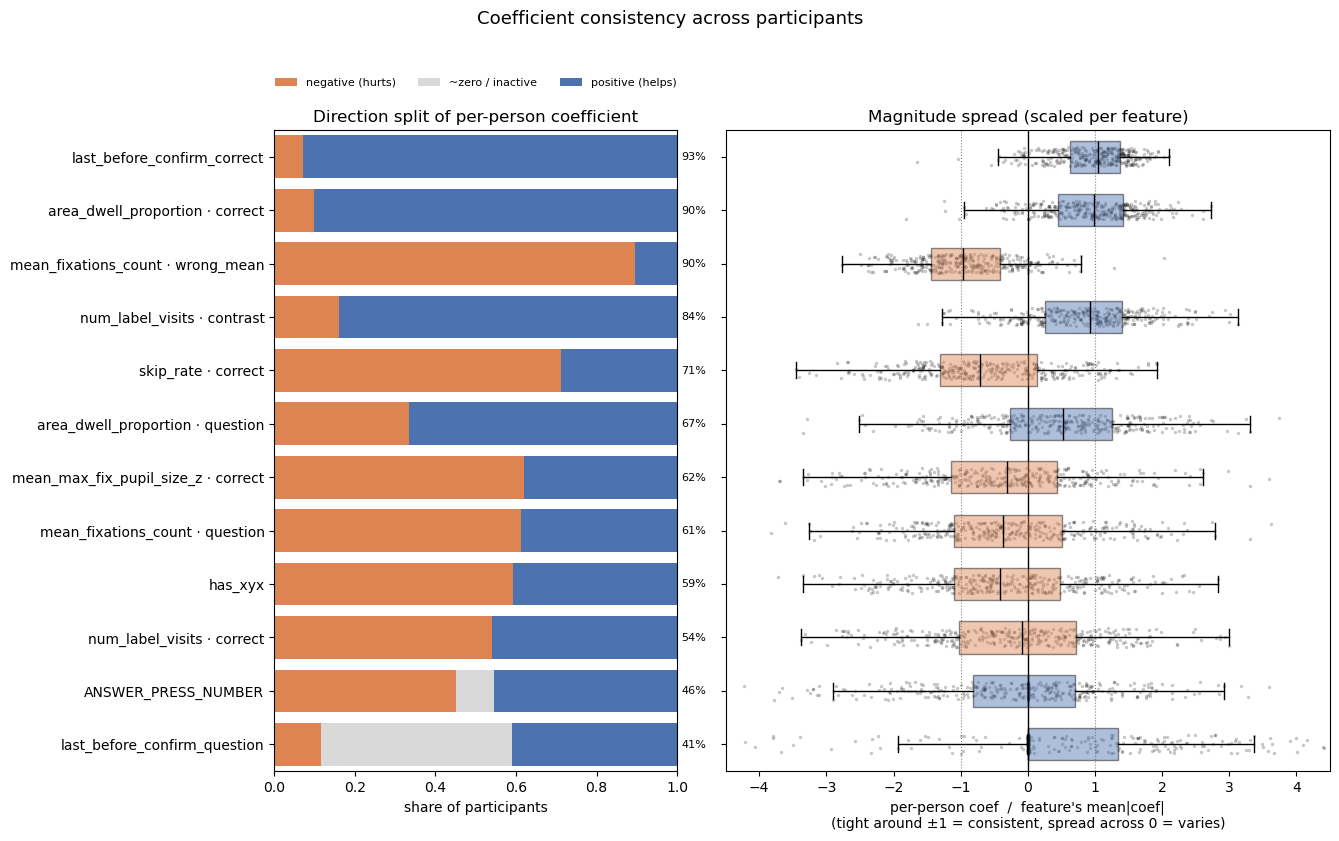

In [9]:
long_coef_df, consistency_df = CC.per_feature_coef_consistency(results_by_pid)
display(consistency_df[CC.CONSISTENCY_DISPLAY_COLS].round(3))

fig_consistency, _ = CC.plot_coef_consistency(long_coef_df, consistency_df)

## Consistency for *all* features (marginal associations)

The section above needs per-person model **coefficients**, so it only covers the
12 trained features. To ask the same "same for everyone vs varies?" question for
**every** feature, we switch to a per-person **marginal** measure that needs no
model: for each participant, the Spearman correlation of each feature with
`is_correct` over that person's own trials. Then we look at how consistent that
association is across participants — the same direction-split + spread view.

Two things to keep in mind:

- This is a **marginal** (unadjusted) association, not the model's **partial**
  coefficient. A feature can be consistent on its own yet unstable once the other
  features are held fixed (collinearity), and vice-versa — so this *complements*
  the trained-feature view, it doesn't replace it. (Reassuringly,
  `last_before_confirm_correct` and `area_dwell_proportion__correct` top both.)
- Only participants with enough trials and **both** outcome classes (`>= 5`
  correct **and** `>= 5` wrong) can be scored, so `n` here is smaller than 356,
  and a constant feature within a person is skipped (tracked as `coverage`). With
  ~50 trials per person these per-person correlations are still noisy, so read
  `dominant_share` near 0.5 as "no reliable direction," not proof of a real split.

The two plots show the strongest marginal signals (which happen to be very
consistent) and, among the strongest features, the ones that most **flip
direction** between people.

participants: kept 288, dropped 72 (need >= 20 trials and >= 5 of each class)


,feature,n_valid,coverage,mean_r,dominant_share,std_r,mean_abs_r
0,last_before_confirm_correct,288,1.0,0.466,0.997,0.193,0.466
1,last_before_select_correct,288,1.0,0.427,0.993,0.186,0.428
2,area_dwell_proportion__correct,288,1.0,0.382,0.997,0.146,0.383
3,area_dwell_proportion__contrast,288,1.0,0.379,0.993,0.146,0.380
4,TimeSinceOffset_normalized_wrong_mean,288,1.0,-0.363,0.993,0.118,0.364
5,RT_normalized_wrong_mean,288,1.0,-0.362,0.997,0.117,0.362
6,RT_normalized_contrast,288,1.0,0.356,0.958,0.164,0.361
7,mean_dwell_time__wrong_mean,288,1.0,-0.355,0.993,0.119,0.356
8,TFD_normalized_wrong_mean,288,1.0,-0.355,0.993,0.119,0.356
9,TFD_normalized_contrast,288,1.0,0.339,0.965,0.163,0.345


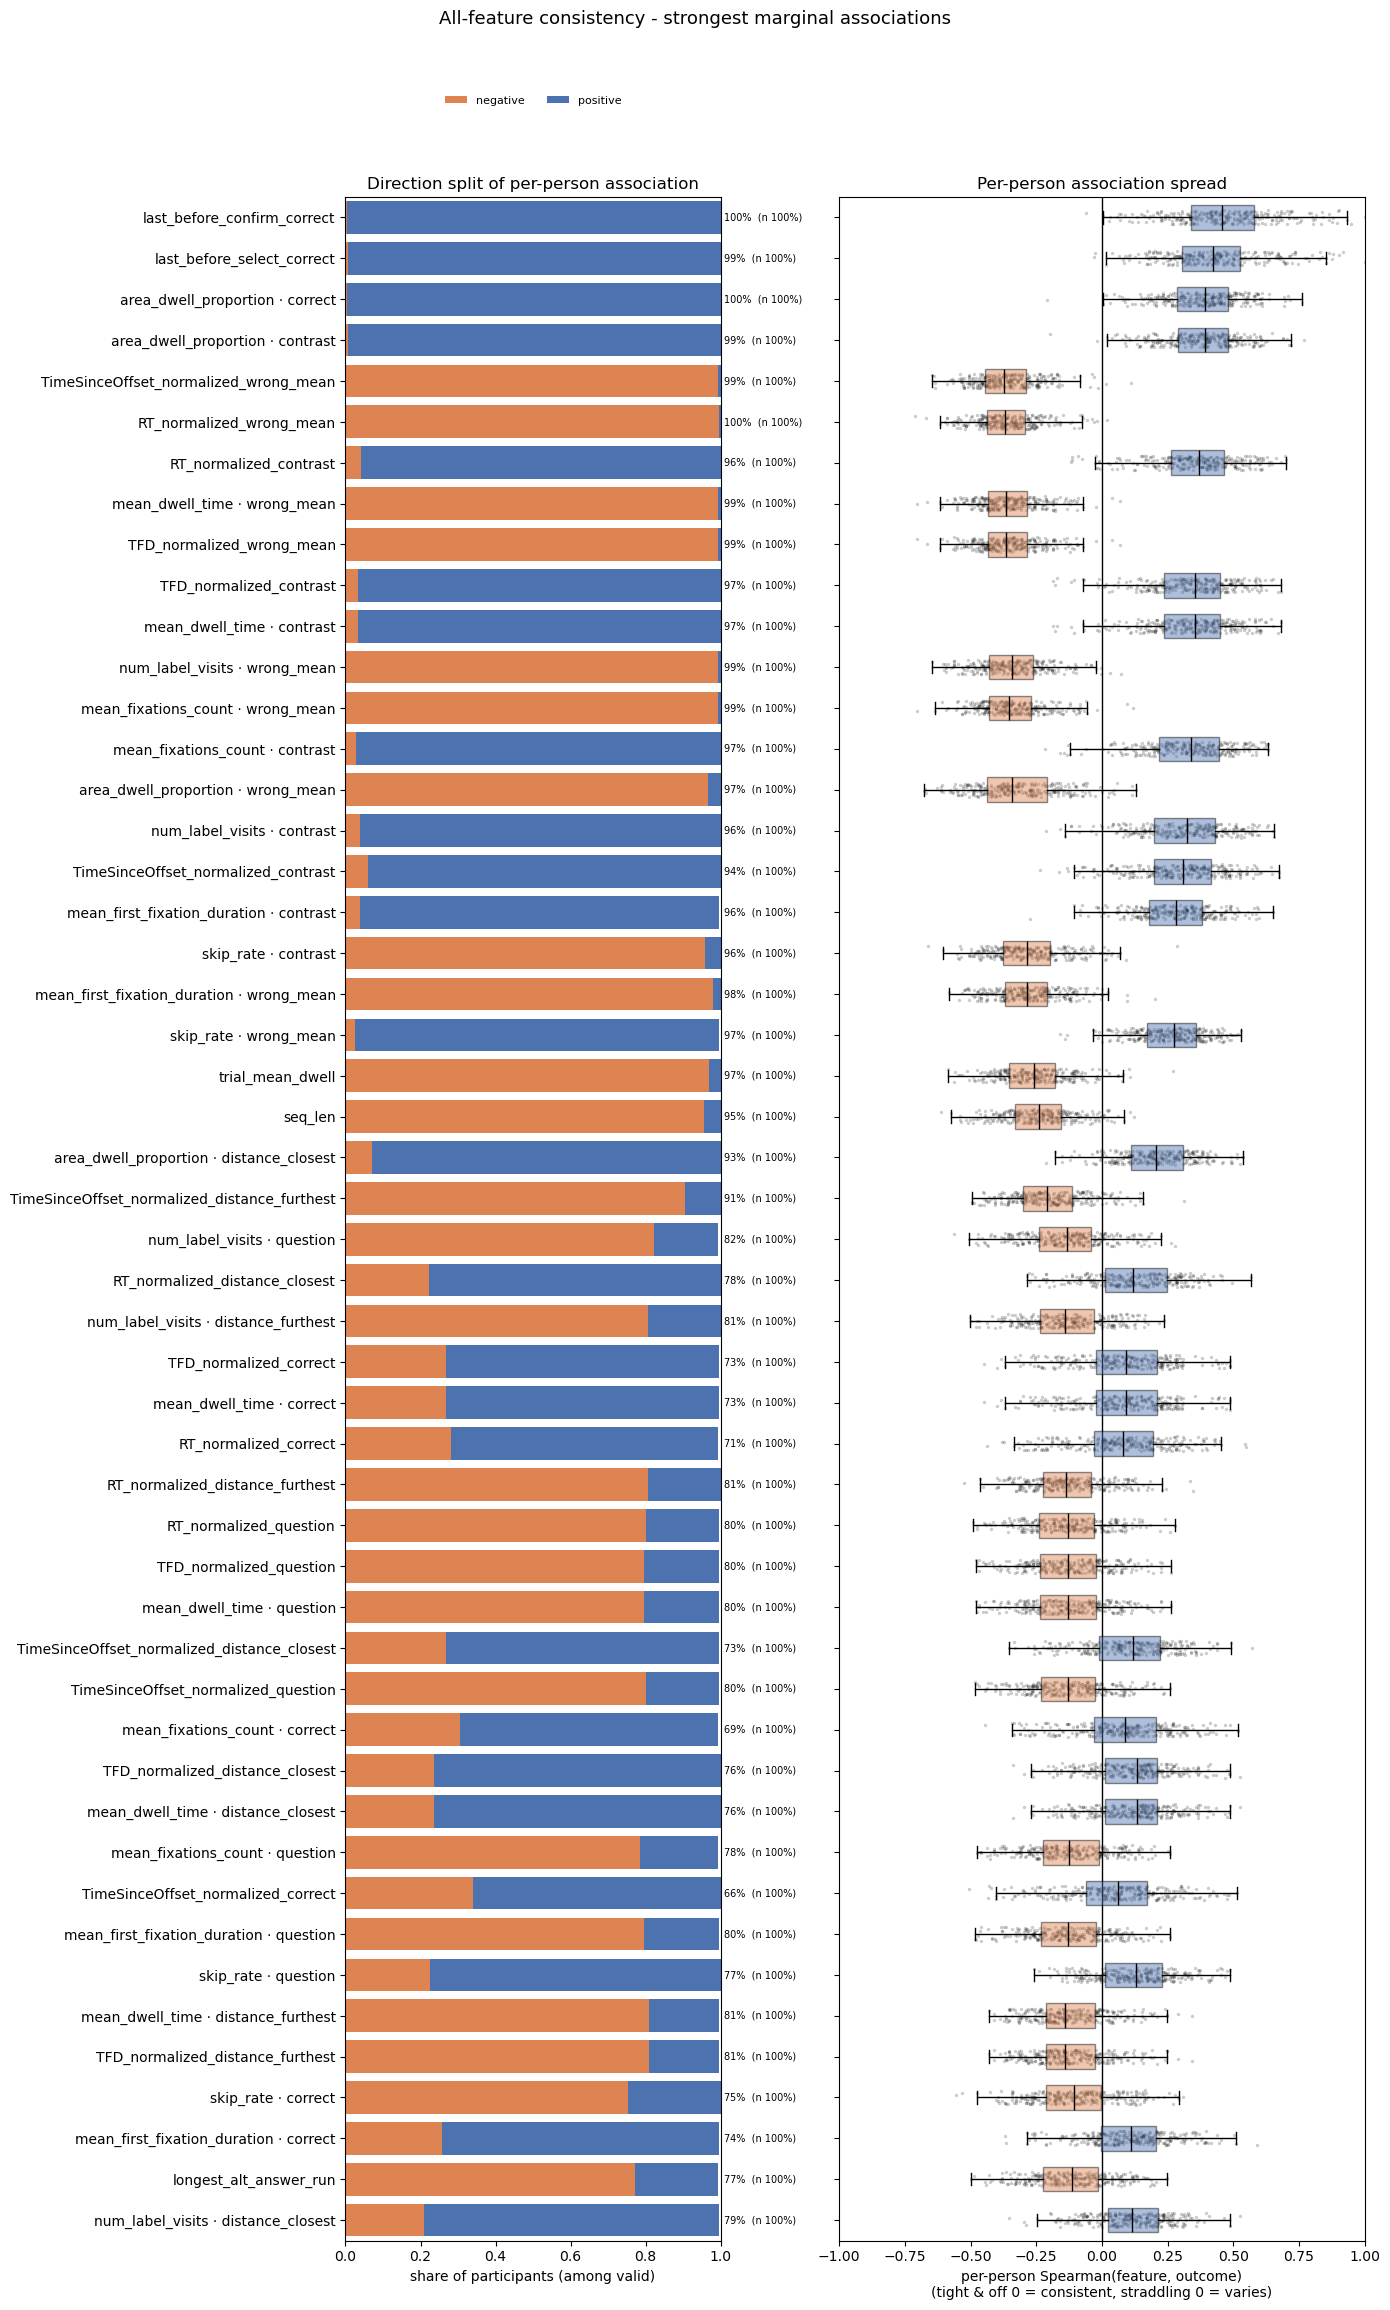

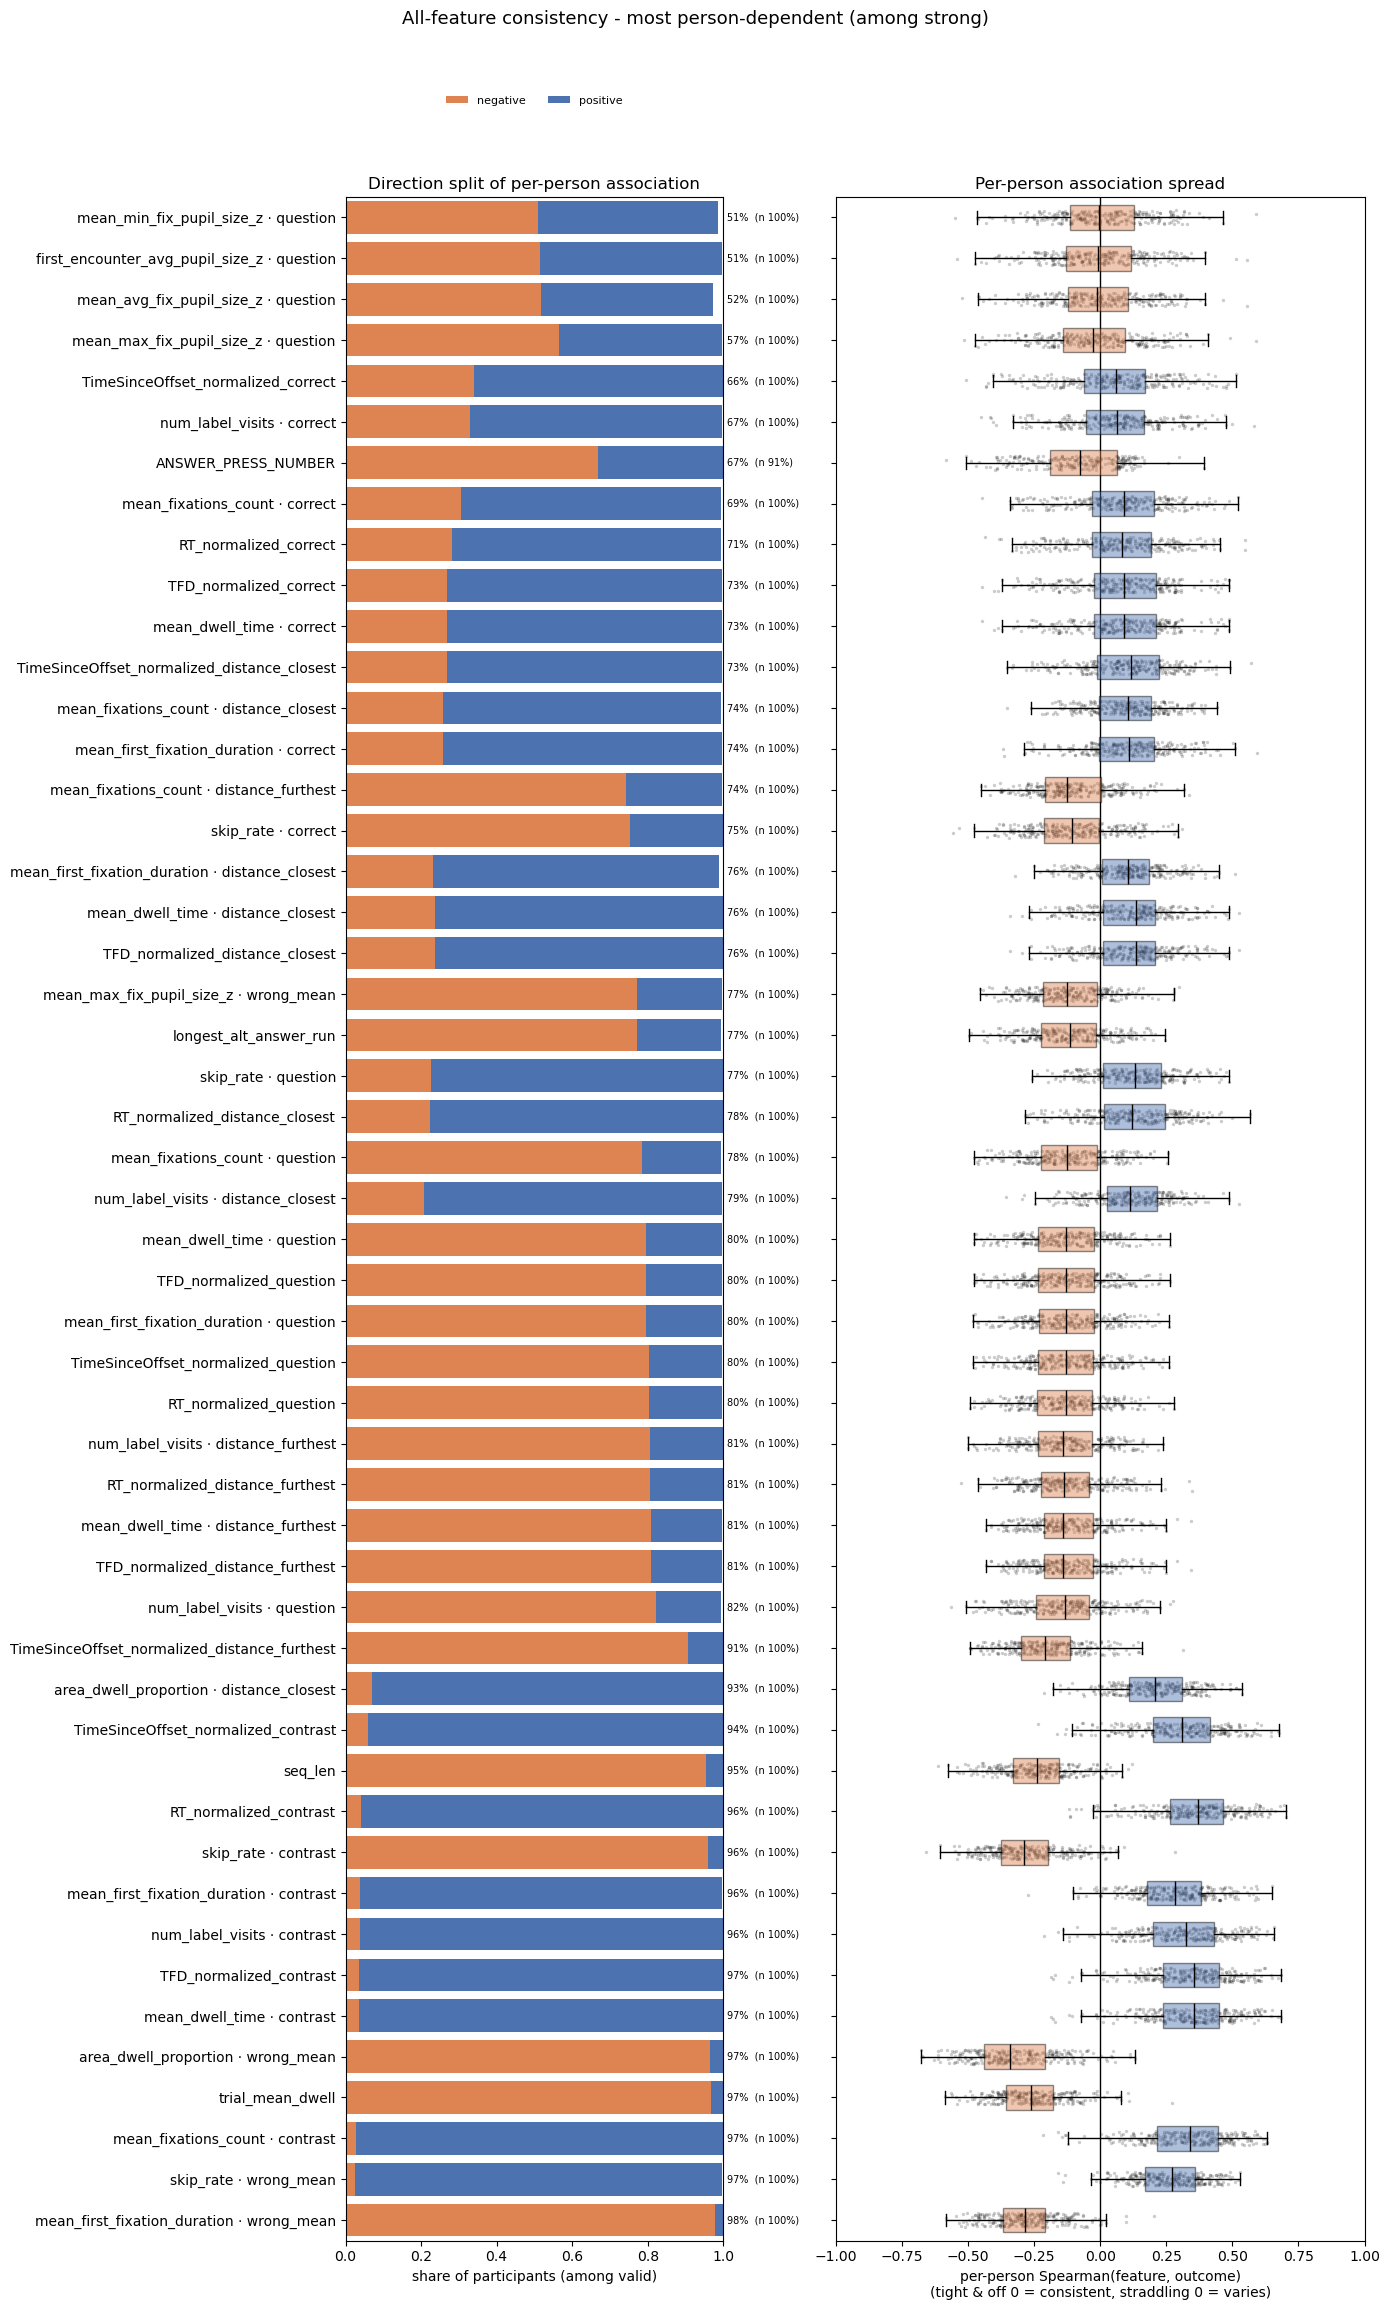

In [10]:
ALL_FEATURE_COLS = [c for c in FG.ALL_FEATURES if c in trial_df.columns]

rmat_uni, uni_consistency_df = UC.per_person_univariate_consistency(
    trial_df, ALL_FEATURE_COLS
)
display(uni_consistency_df[UC.UNIVARIATE_DISPLAY_COLS].round(3).head(20))

# Strongest marginal signals (these tend to be the most consistent, too):
fig_uni_strong, _ = UC.plot_univariate_consistency(
    rmat_uni, uni_consistency_df, top_k=50,
    title="All-feature consistency - strongest marginal associations",
)

# Where does a real marginal signal FLIP between people? Among the 60 strongest
# features, show the least directionally consistent ones.
fig_uni_varying, _ = UC.plot_univariate_consistency(
    rmat_uni, UC.most_person_dependent(uni_consistency_df, n_strongest=60), top_k=50,
    title="All-feature consistency - most person-dependent (among strong)",
)

## What characterizes low-/high-accuracy participants?

Relate each participant's *mean* feature value to how well the per-person model
scores them (`AC.ACC_METRIC`), then contrast the low- vs high-accuracy terciles.

Two guards keep the comparison honest:

- **`AC.MIN_WRONG_TRIALS`** filters out participants with too few wrong
  (minority-class) trials, where balanced accuracy is essentially unestimable and
  collapses toward chance (this also drops the single-class participants that have
  no balanced accuracy at all).
- The analysis is run **twice** - once on **only the features the model was
  trained on** (`FEATURE_COLS`), once on **all available features**
  (`FG.ALL_FEATURES`). Comparing the two separates *"the model
  struggles where its own inputs are weak"* from *"a characteristic sits in
  features the model never sees"* (a potential confound).

Pass `acc_metric="accuracy"` for raw accuracy instead of balanced accuracy, and
`min_wrong_trials=` to change the estimability guard.

### Graph set 1 - features the model trained on

Only the 12 `FEATURE_COLS`. This tells you *where the model's own inputs carry
(or lack) per-person signal*.

[trained features] 197/356 participants kept (n_wrong_trials >= 8); characterizing 'balanced_accuracy' over 12 features
[trained features] low: 66 (balanced_accuracy <= 0.737)  |  high: 66 (balanced_accuracy >= 0.833)
    base_rate_correct : low=0.791  high=0.779
    minority_rate     : low=0.209  high=0.221
    n_trials          : low=53.985  high=53.985


,feature,spearman_r,abs_r
0,last_before_confirm_correct,0.402427,0.402427
1,has_xyx,0.386316,0.386316
2,area_dwell_proportion__correct,0.336400,0.336400
3,num_label_visits__contrast,0.290277,0.290277
4,mean_max_fix_pupil_size_z__correct,0.194386,0.194386
5,last_before_confirm_question,-0.184290,0.184290
6,area_dwell_proportion__question,-0.175244,0.175244
7,skip_rate__correct,-0.166485,0.166485
8,num_label_visits__correct,0.145095,0.145095
9,mean_fixations_count__question,-0.116966,0.116966


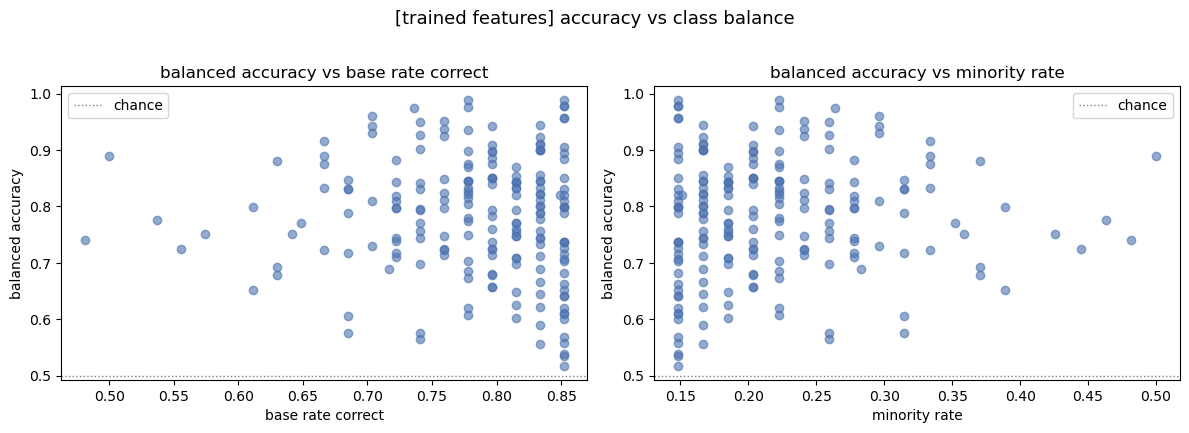

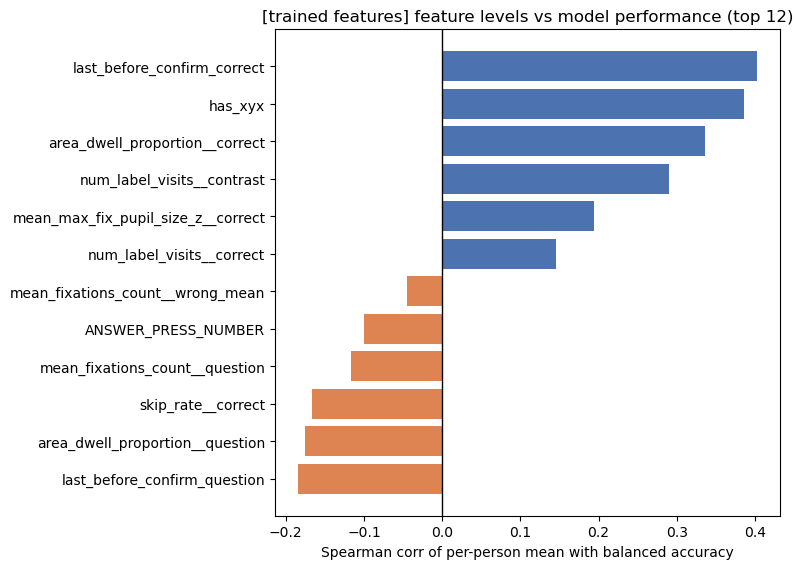

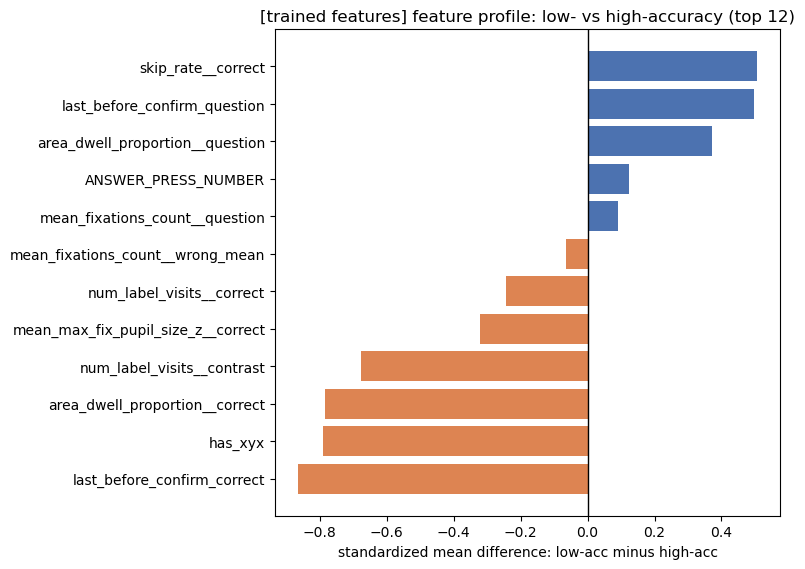

In [11]:
trained_out = AC.characterize_accuracy(
    summary_df,
    trial_df,
    characterize_cols=FEATURE_COLS,
    label="trained features",
)
display(trained_out["feat_corr"])


# separate into ppl with % correct trials
# 4 cases - correct on wrong, correct on right, wrong on...

### Graph set 2 - all available features

Every feature in the table, including many the model never sees. Anything that
separates low- from high-accuracy participants **here but not above** is a
characteristic outside the model's inputs - a candidate confound worth a look.

[all features] 197/356 participants kept (n_wrong_trials >= 8); characterizing 'balanced_accuracy' over 98 features
[all features] low: 66 (balanced_accuracy <= 0.737)  |  high: 66 (balanced_accuracy >= 0.833)
    base_rate_correct : low=0.791  high=0.779
    minority_rate     : low=0.209  high=0.221
    n_trials          : low=53.985  high=53.985


,feature,spearman_r,abs_r
0,num_label_visits__distance_closest,0.409503,0.409503
1,last_before_confirm_correct,0.402427,0.402427
2,has_xyx,0.386316,0.386316
3,area_dwell_proportion__correct,0.336400,0.336400
4,area_dwell_proportion__contrast,0.322700,0.322700
5,area_dwell_proportion__distance_closest,0.318081,0.318081
6,num_label_visits__contrast,0.290277,0.290277
7,last_before_select_correct,0.272178,0.272178
8,mean_fixations_count__contrast,0.266795,0.266795
9,skip_rate__contrast,-0.263961,0.263961


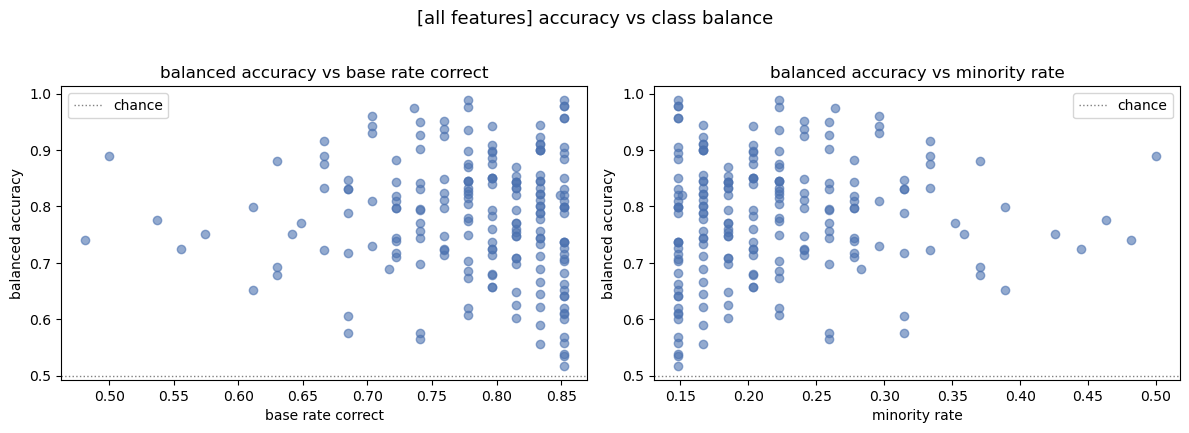

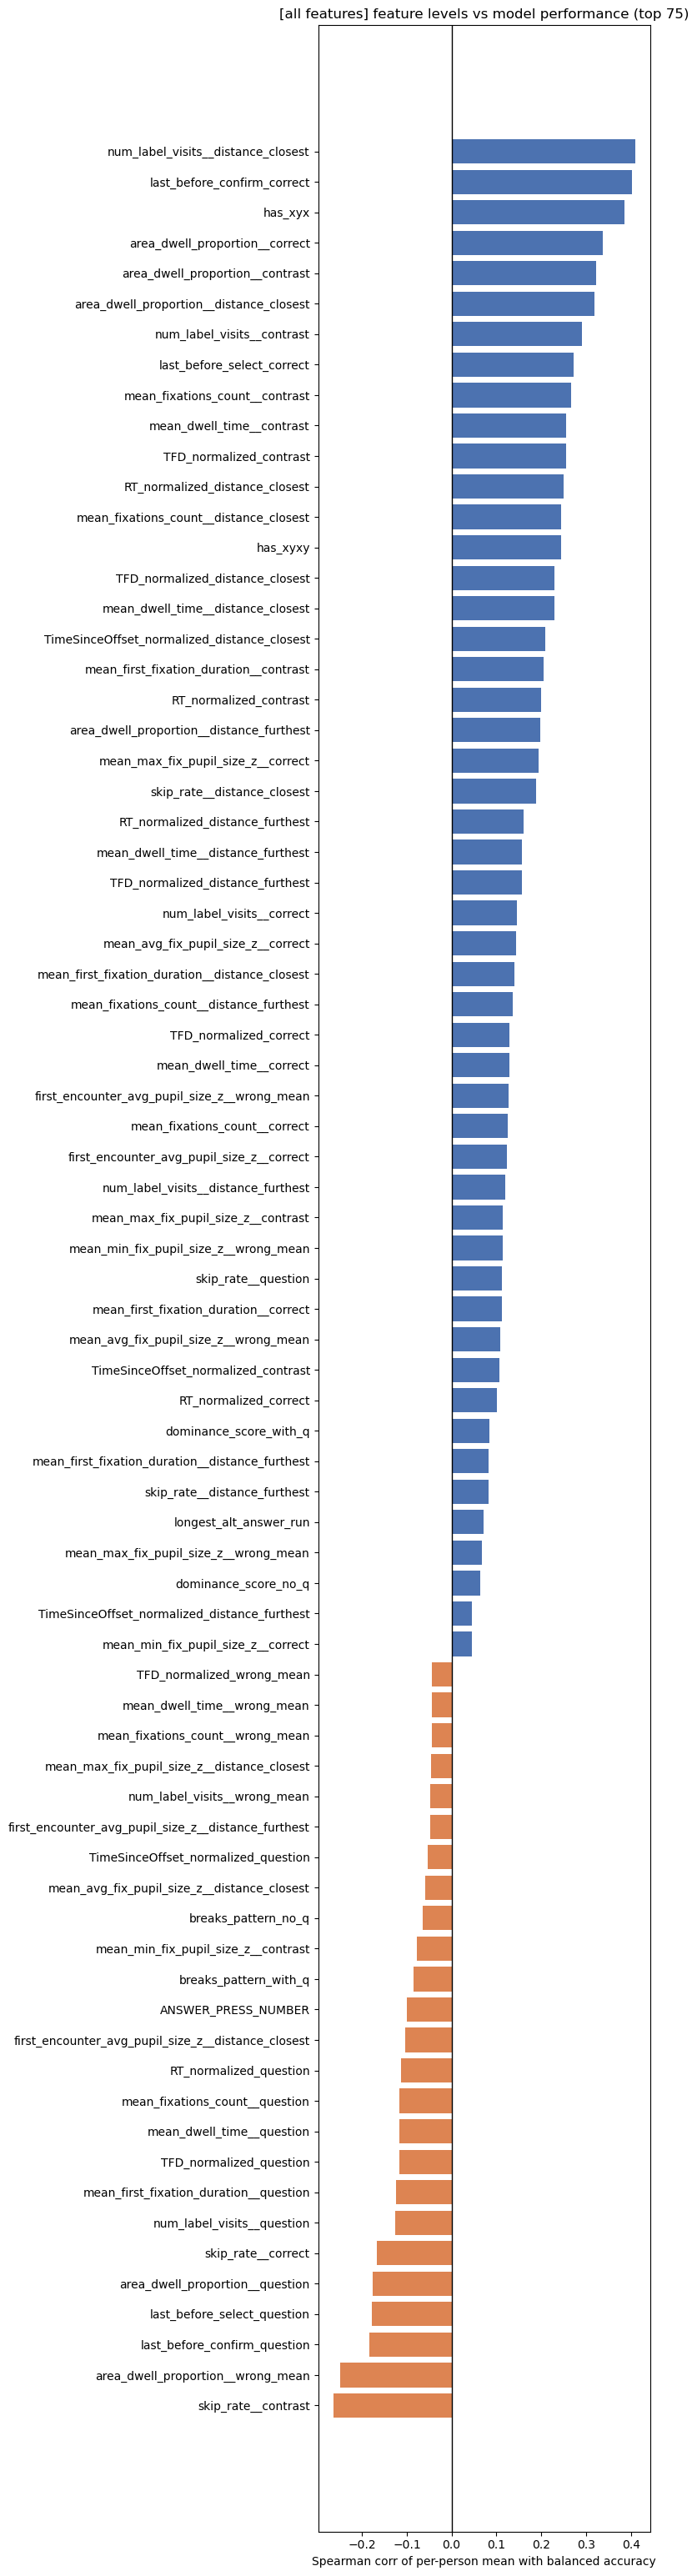

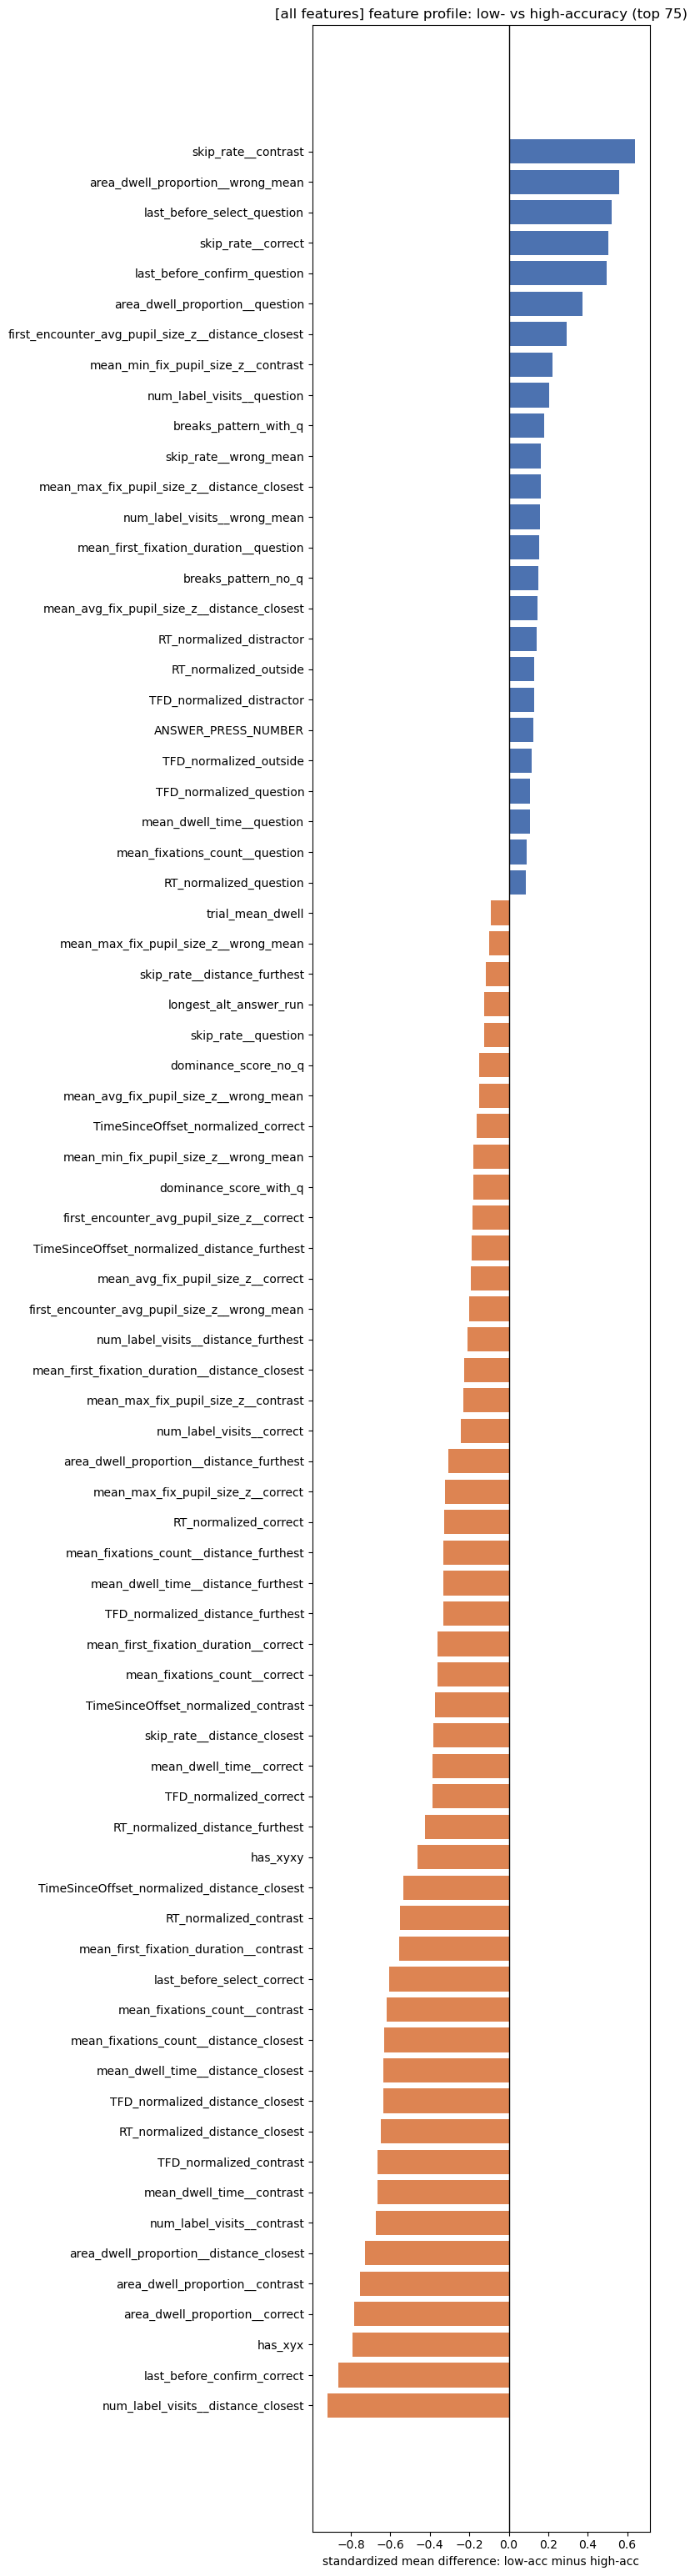

In [12]:
all_out = AC.characterize_accuracy(
    summary_df,
    trial_df,
    characterize_cols=FG.ALL_FEATURES,
    label="all features",
    top_n_bars=75,
)
display(all_out["feat_corr"].head(30))

Graph 1

Positive bar (blue): people who do more of this behavior are people the model predicts better. This trait marks a model-friendly participant.
Negative bar (orange): people who do more of this are people the model predicts worse. This trait marks a model-hostile participant.

has_xyx — back-and-forth comparison between options. The single clearest marker: people who actively compare answers are the ones the model reads most reliably.

skip_rate__correct at −0.17 -- Participants who skim the correct answer — leave a larger share of its words unread — tend to be predicted worse (lower balanced accuracy). People whose average correct-answer skip rate is high are people the model predicts worse (lower balanced accuracy).

Graph 2
Blue (positive): trait is elevated in the people the model does worst on → the model-hostile signature.
Orange (negative): trait is elevated in the people the model does best on → the model-friendly signature.

## Mistake types - decomposing the feature/accuracy association

The section above relates features to a single `balanced_accuracy` per person.
Here we break that down by *what kind of mistake* the model makes, using the
confusion matrix (`is_correct = 1` means the human answered correctly):

|                   | model says correct | model says wrong |
|-------------------|--------------------|------------------|
| **human correct** | TP - correct on right | FN - miss     |
| **human wrong**   | FP - false alarm   | TN - correct on wrong |

Two complementary views:
1. **Trial-level** - pool all held-out trials, label each quadrant, and compare
   feature profiles between mistakes and hits of the same true label.
2. **Per-person** - split balanced accuracy into sensitivity ("correct on right")
   and specificity ("correct on wrong"), and rerun the per-feature correlation
   for each half.

19215 pooled held-out trials from 356 participants

Confusion quadrants (pooled over all trials):
  TP - correct on right   13872  ( 72.2%)
  TN - correct on wrong    2141  ( 11.1%)
  FP - false alarm          951  (  4.9%)
  FN - miss                2251  ( 11.7%)

Errors: 3202 total  |  FP false alarms 29.7%  |  FN misses 70.3%


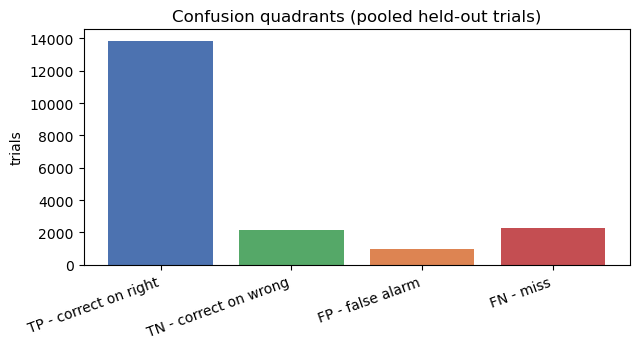

In [13]:
trials = MT.build_trial_prediction_table(results_by_pid)
quad_counts = MT.summarize_confusion_quadrants(trials)

fig_quad, _ = MT.plot_confusion_quadrants(quad_counts)

### View 1 (trial-level) - what do the mistake trials look like?

Every held-out trial falls in one confusion quadrant. `test_df` on each result is
row-aligned with `y_true`/`y_pred` and already carries the feature columns, so we
can pool them and compare feature profiles per quadrant with no re-merge.

quadrant,TP,TN,FP,FN,FN - TP | human correct (+) = elevated on misses,FP - TN | human wrong (+) = elevated on false alarms
area_dwell_proportion__correct,0.255,-0.936,-0.432,-0.496,-0.751,0.504
area_dwell_proportion__question,-0.055,0.165,0.121,0.131,0.186,-0.044
skip_rate__correct,-0.065,0.264,0.065,0.125,0.190,-0.200
has_xyx,-0.033,0.185,0.038,0.009,0.041,-0.147
ANSWER_PRESS_NUMBER,-0.063,0.223,0.127,0.121,0.184,-0.097
num_label_visits__correct,-0.003,-0.102,0.189,0.033,0.036,0.291
num_label_visits__contrast,0.199,-0.883,-0.163,-0.318,-0.517,0.721
mean_fixations_count__question,-0.110,0.425,0.243,0.169,0.278,-0.182
mean_fixations_count__wrong_mean,-0.217,0.864,0.361,0.364,0.581,-0.502
mean_max_fix_pupil_size_z__correct,-0.016,0.069,0.078,0.006,0.022,0.010


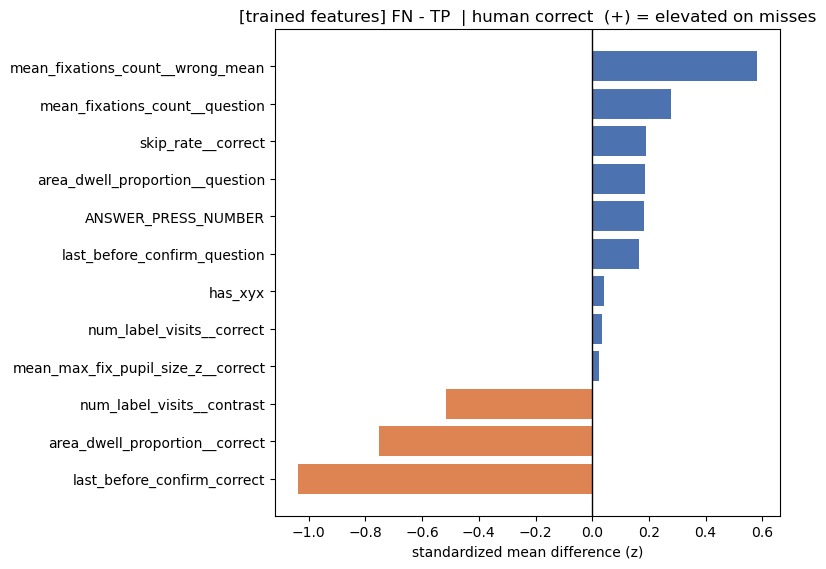

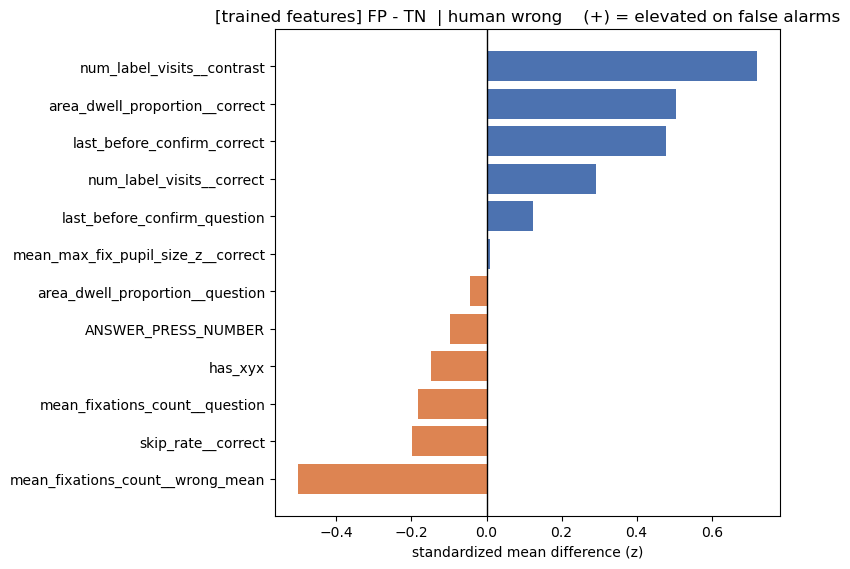

In [14]:
quad_trained = MT.trial_feature_profile_by_quadrant(
    trials, FEATURE_COLS, label="trained features"
)
display(quad_trained["mean_z"].round(3))

#### All features (trial-level)

Same mistake-vs-hit contrasts, but over **every** feature (`FG.ALL_FEATURES`),
including the ~86 the model never trained on. A feature that separates a mistake
from a hit **here but not in the trained set above** is signal the model isn't
using — a candidate input (or confound) worth a look. Standardization is again
over all pooled trials, so each bar is "how far this quadrant sits from the
typical trial."

quadrant,TP,TN,FP,FN,FN - TP | human correct (+) = elevated on misses,FP - TN | human wrong (+) = elevated on false alarms
mean_dwell_time__correct,-0.006,-0.069,0.063,0.073,0.078,0.131
mean_fixations_count__correct,-0.003,-0.070,0.078,0.054,0.057,0.148
mean_first_fixation_duration__correct,0.050,-0.218,-0.067,-0.073,-0.123,0.151
skip_rate__correct,-0.065,0.264,0.065,0.125,0.190,-0.200
area_dwell_proportion__correct,0.255,-0.936,-0.432,-0.496,-0.751,0.504
...,...,...,...,...,...,...
TimeSinceOffset_normalized_distance_closest,0.024,-0.040,-0.132,-0.056,-0.080,-0.092
last_before_confirm_correct,0.333,-1.129,-0.650,-0.705,-1.038,0.479
last_before_confirm_question,-0.021,-0.051,0.073,0.146,0.166,0.124
last_before_select_correct,0.214,-0.960,-0.783,-0.076,-0.291,0.177


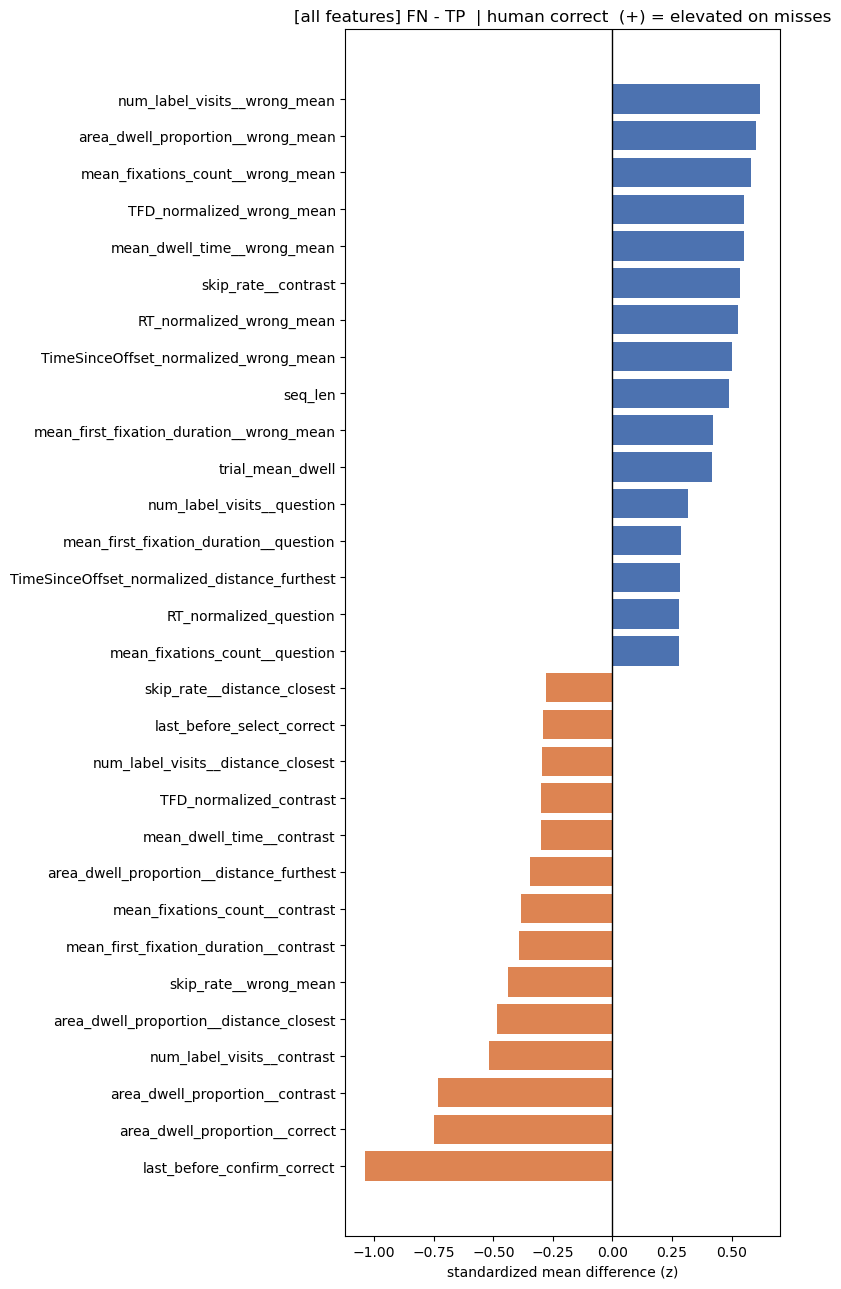

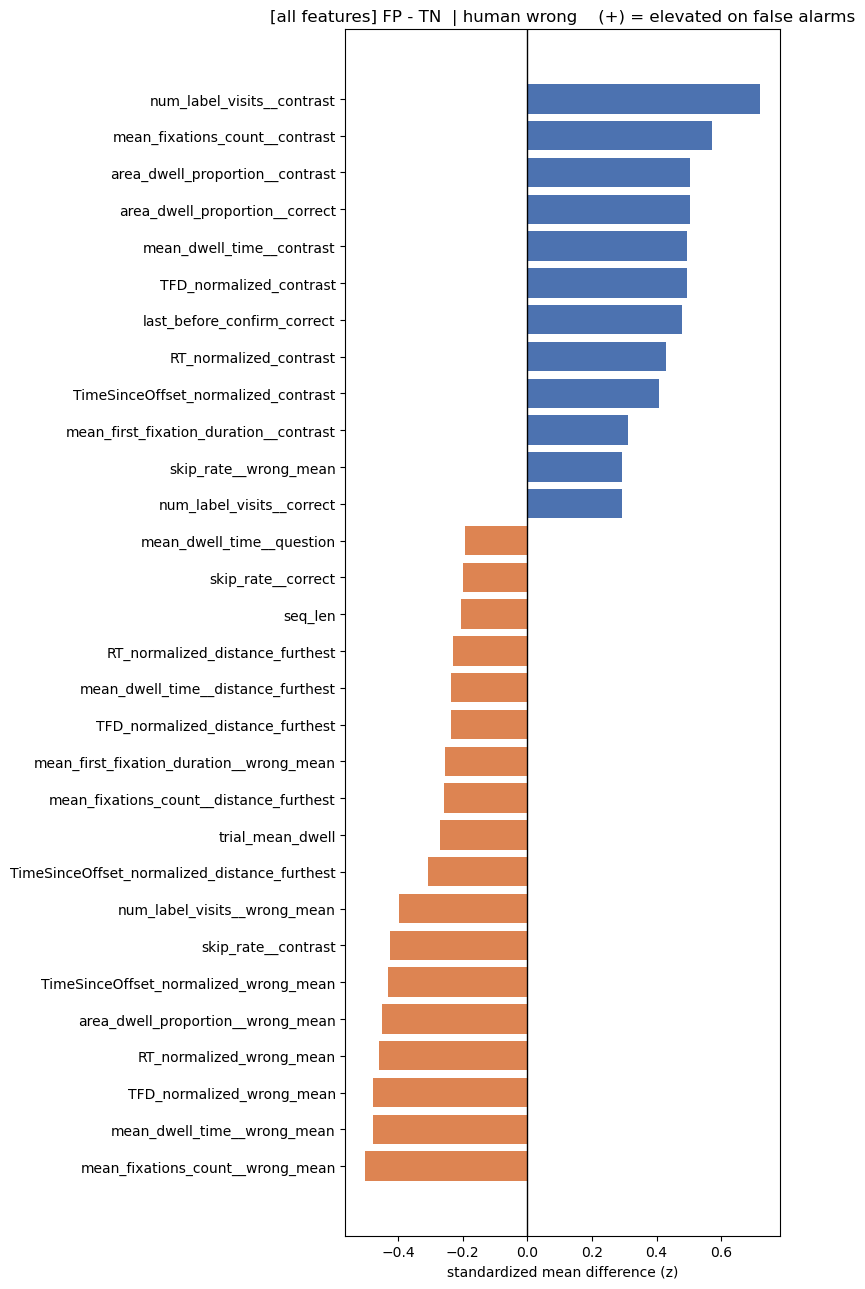

In [15]:
quad_all = MT.trial_feature_profile_by_quadrant(
    trials, FG.ALL_FEATURES, top_n_bars=30, label="all features",
)
display(quad_all["mean_z"].round(3))

### View 2 (per-person) - split balanced accuracy by mistake type

Balanced accuracy is the average of two conditional accuracies, so a single
`feature vs balanced_accuracy` correlation blurs them together. Here we split it:
correlate each participant's *mean* feature value with **sensitivity** ("correct
on right") and with **specificity** ("correct on wrong") separately. This is the
same per-feature Spearman analysis as the section above, just run once per half.

[trained features] sensitivity : 356 participants (n_correct_trials >= 8)
[trained features] specificity : 197 participants (n_wrong_trials >= 8)


,feature,r_sensitivity,r_specificity,r_balacc,max_abs
0,last_before_confirm_correct,0.502032,0.323015,0.402427,0.502032
1,has_xyx,0.183778,0.361087,0.386316,0.361087
2,area_dwell_proportion__correct,0.346890,0.256423,0.336400,0.346890
3,num_label_visits__contrast,0.333531,0.213886,0.290277,0.333531
4,mean_fixations_count__question,-0.212097,-0.097887,-0.116966,0.212097
5,area_dwell_proportion__question,-0.207045,-0.161047,-0.175244,0.207045
6,mean_max_fix_pupil_size_z__correct,0.111214,0.194742,0.194386,0.194742
7,last_before_confirm_question,-0.147481,-0.184359,-0.184290,0.184359
8,skip_rate__correct,-0.126179,-0.171663,-0.166485,0.171663
9,ANSWER_PRESS_NUMBER,-0.131120,-0.109654,-0.100409,0.131120


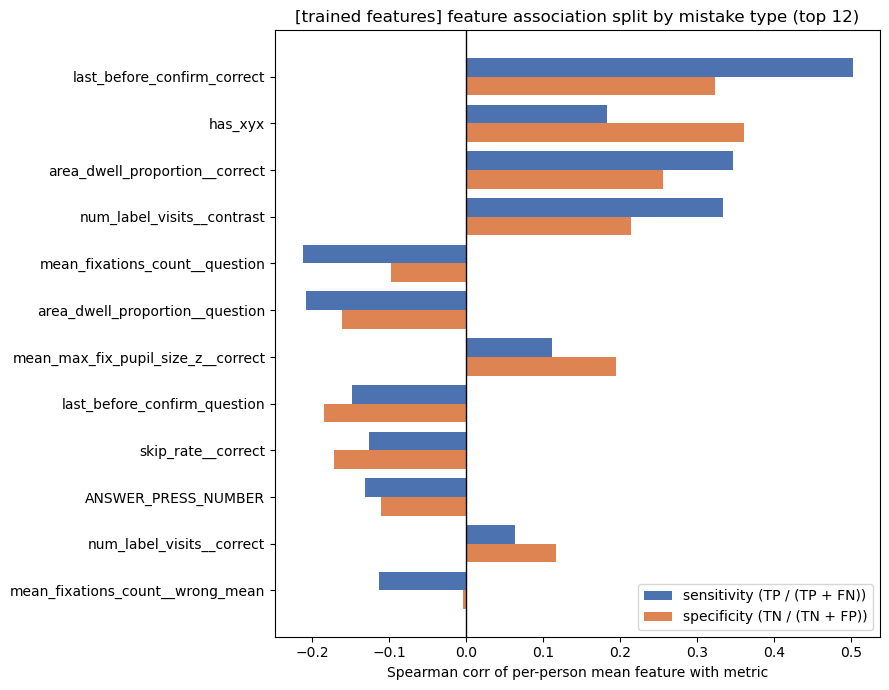

In [16]:
conf_df = MT.per_person_confusion(results_by_pid)

err_trained = MT.characterize_accuracy_by_error_type(
    conf_df, trial_df, characterize_cols=FEATURE_COLS, label="trained features",
)
display(err_trained["corr"])

#### All features (per-person)

The same sensitivity-vs-specificity split, but correlating **every** feature's
per-person mean with each half of balanced accuracy. Features that track the
model's skill on one kind of trial (or the other) **here but not in the trained
set** point to per-person structure the model's own inputs don't capture. `n`
differs per half: specificity needs enough wrong trials, so fewer participants
qualify.

[all features] sensitivity : 356 participants (n_correct_trials >= 8)
[all features] specificity : 197 participants (n_wrong_trials >= 8)


,feature,r_sensitivity,r_specificity,r_balacc,max_abs
0,last_before_confirm_correct,0.502032,0.323015,0.402427,0.502032
1,last_before_select_correct,0.389989,0.177092,0.272178,0.389989
2,num_label_visits__distance_closest,0.291969,0.363466,0.409503,0.363466
3,has_xyx,0.183778,0.361087,0.386316,0.361087
4,area_dwell_proportion__correct,0.346890,0.256423,0.336400,0.346890
5,num_label_visits__contrast,0.333531,0.213886,0.290277,0.333531
6,area_dwell_proportion__contrast,0.326185,0.242482,0.322700,0.326185
7,mean_fixations_count__contrast,0.273034,0.208113,0.266795,0.273034
8,area_dwell_proportion__distance_closest,0.256869,0.260984,0.318081,0.260984
9,num_label_visits__question,-0.248376,-0.096405,-0.126652,0.248376


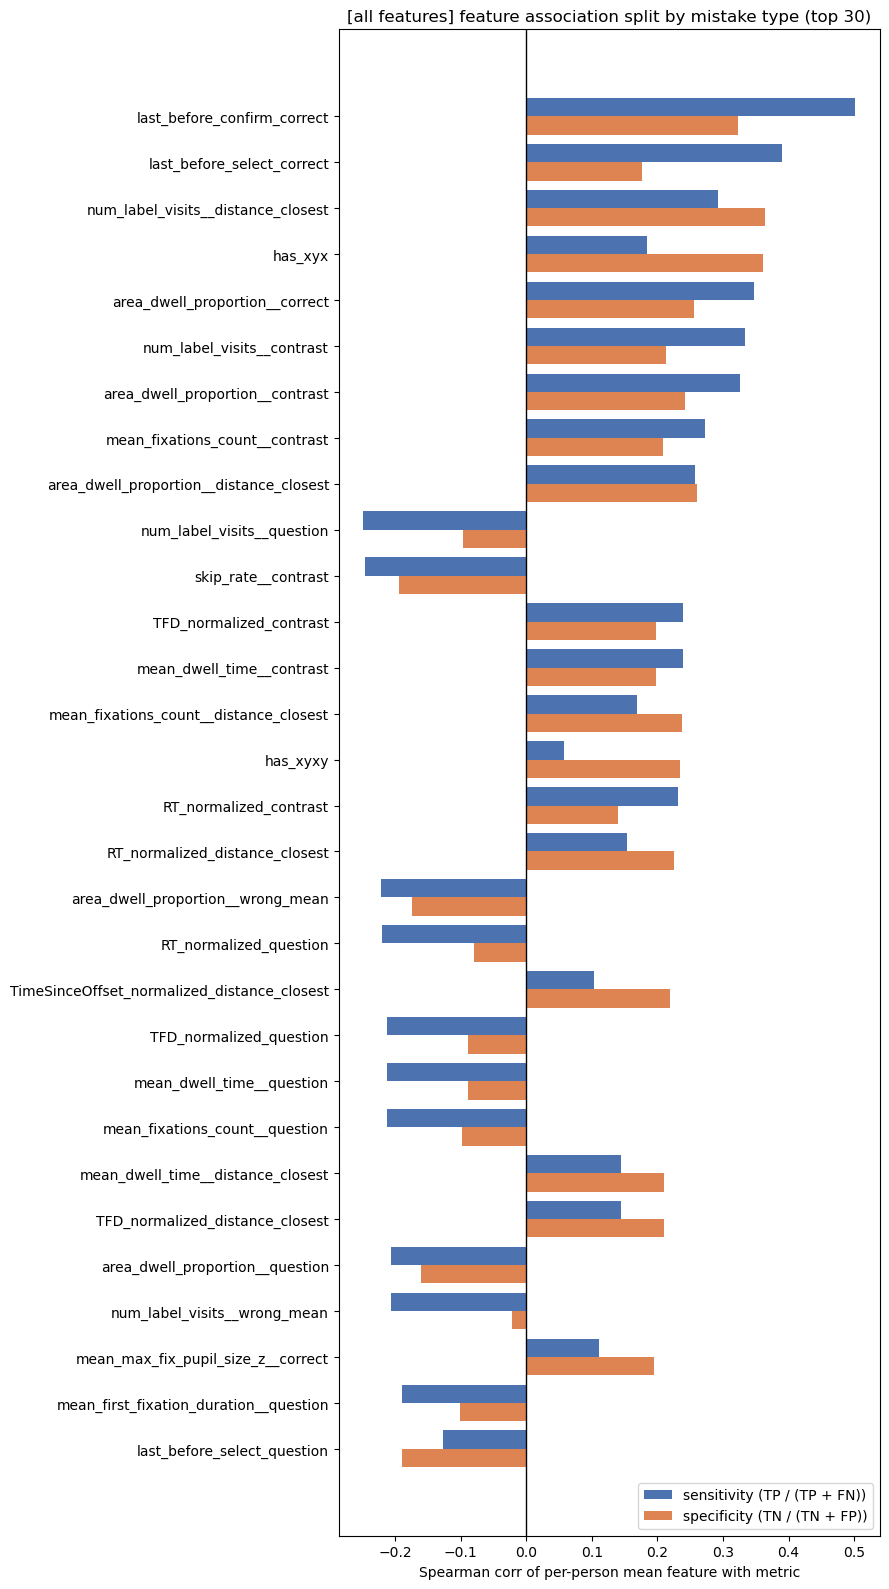

In [17]:
err_all = MT.characterize_accuracy_by_error_type(
    conf_df, trial_df, characterize_cols=FG.ALL_FEATURES,
    top_n_bars=30, label="all features",
)
display(err_all["corr"].head(30))

**How to read the two mistake-type views**

- **Trial-level contrasts** hold the *human's* answer fixed and vary whether the
  model got it right, so each bar is "what a mistake trial looks like versus a
  hit of the same kind":
  - `FN - TP | human correct`: among trials the human answered **correctly**, how
    a **missed** trial's features differ from a **caught** one. `(+)` = the
    feature is elevated on the misses.
  - `FP - TN | human wrong`: among trials the human answered **wrong**, how a
    **false alarm** differs from a correctly-flagged wrong answer.

- **Per-person split** decomposes balanced accuracy into its two halves
  (`balanced_accuracy = (sensitivity + specificity) / 2`):
  - **sensitivity** = "correct on right" = of a person's human-correct trials,
    the share the model catches.
  - **specificity** = "correct on wrong" = of their human-wrong trials, the share
    the model catches.
  A feature whose bars point the *same* way for both helps everywhere; one that
  splits (e.g. `+` for specificity, `~0` for sensitivity) only tracks the model's
  skill at one kind of trial. Compare against the single `r_balacc` column to see
  what the pooled association in the section above was averaging over.

Swap `FEATURE_COLS` for `FG.ALL_FEATURES` in either call to widen the lens to
features the model never trained on (same trained-vs-all split as above).

## Participant-specific coefficient, one feature at a time

Same layout as the mixed-effects "participant-specific effect" plots in
`mixed_text_answer_effects` (sorted dots + whiskers, mean/median reference
lines) -- but the value here is each participant's *own* coefficient from
their full-data logistic fit, and the whisker is that participant's own Wald
95% CI (`ci_method="wald"`, the default in `run_or_load_per_person_loo`), so
whisker widths vary participant to participant instead of coming from one
shared random-effect SD.

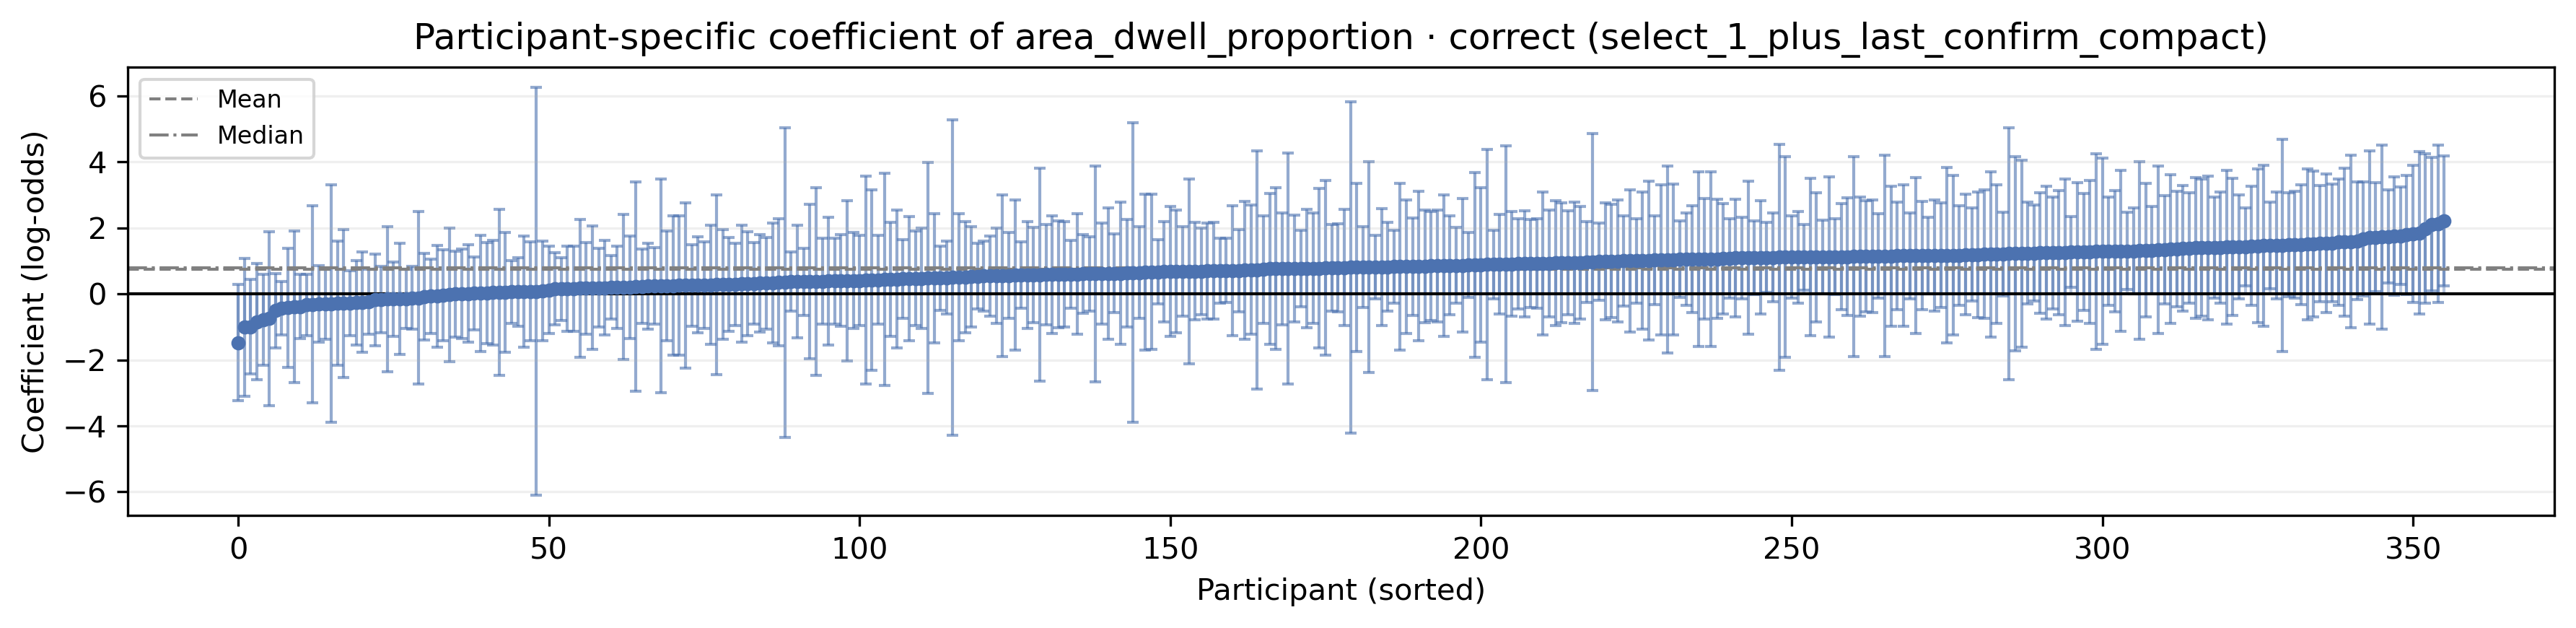

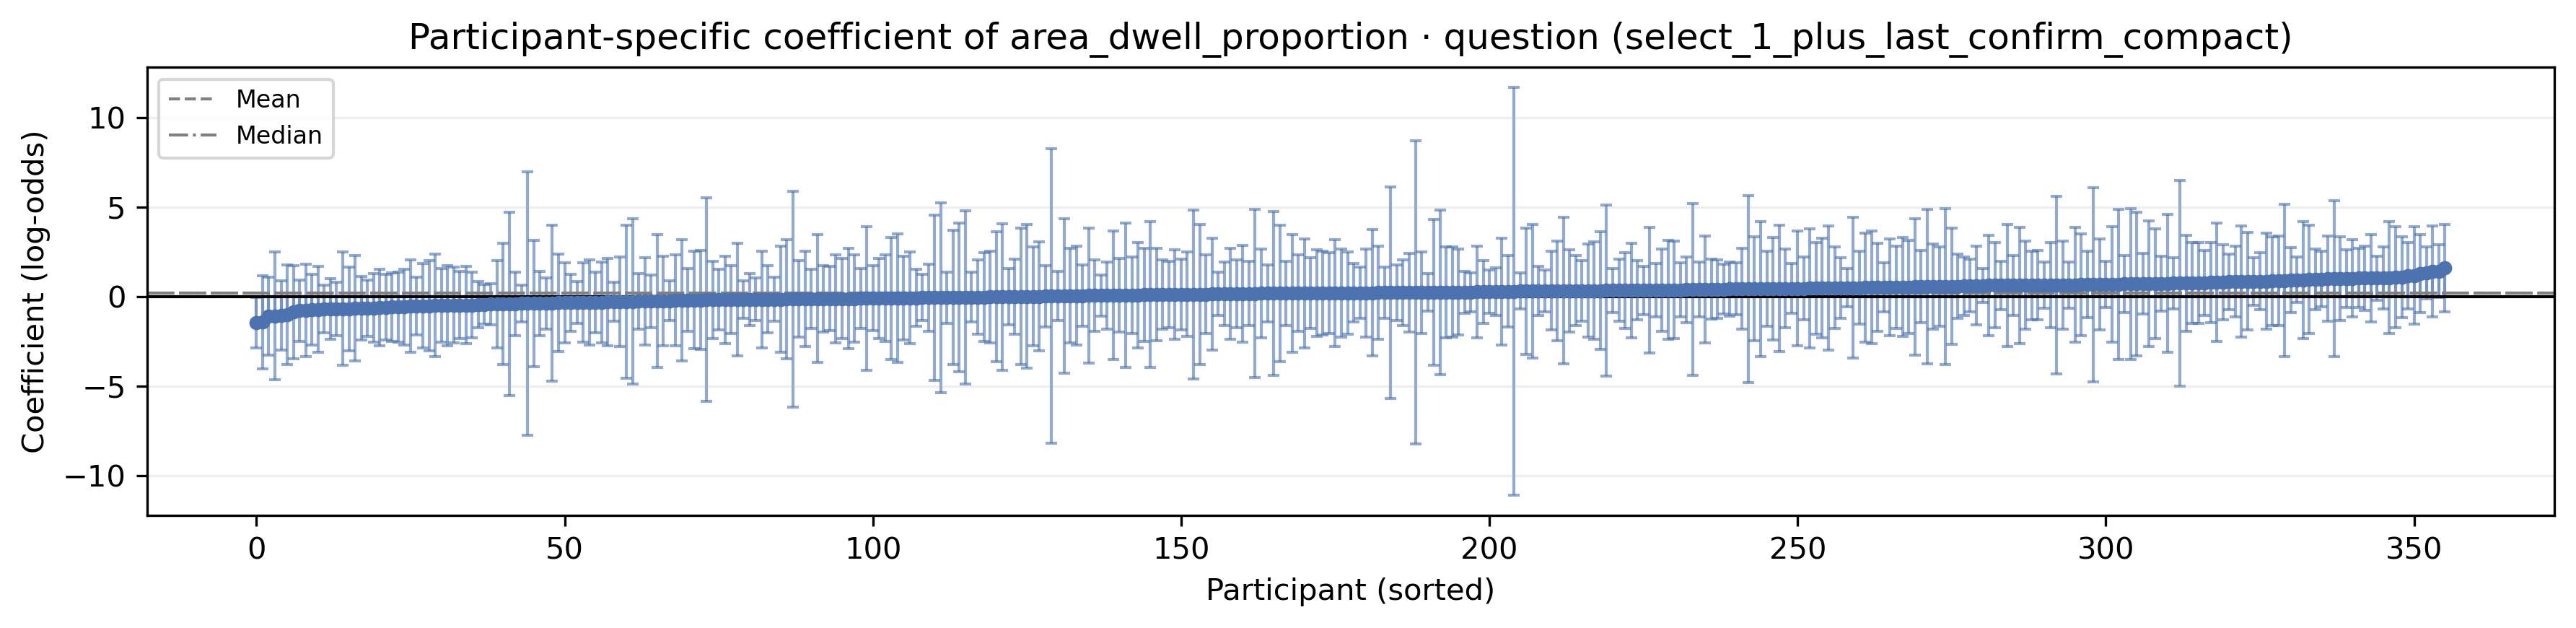

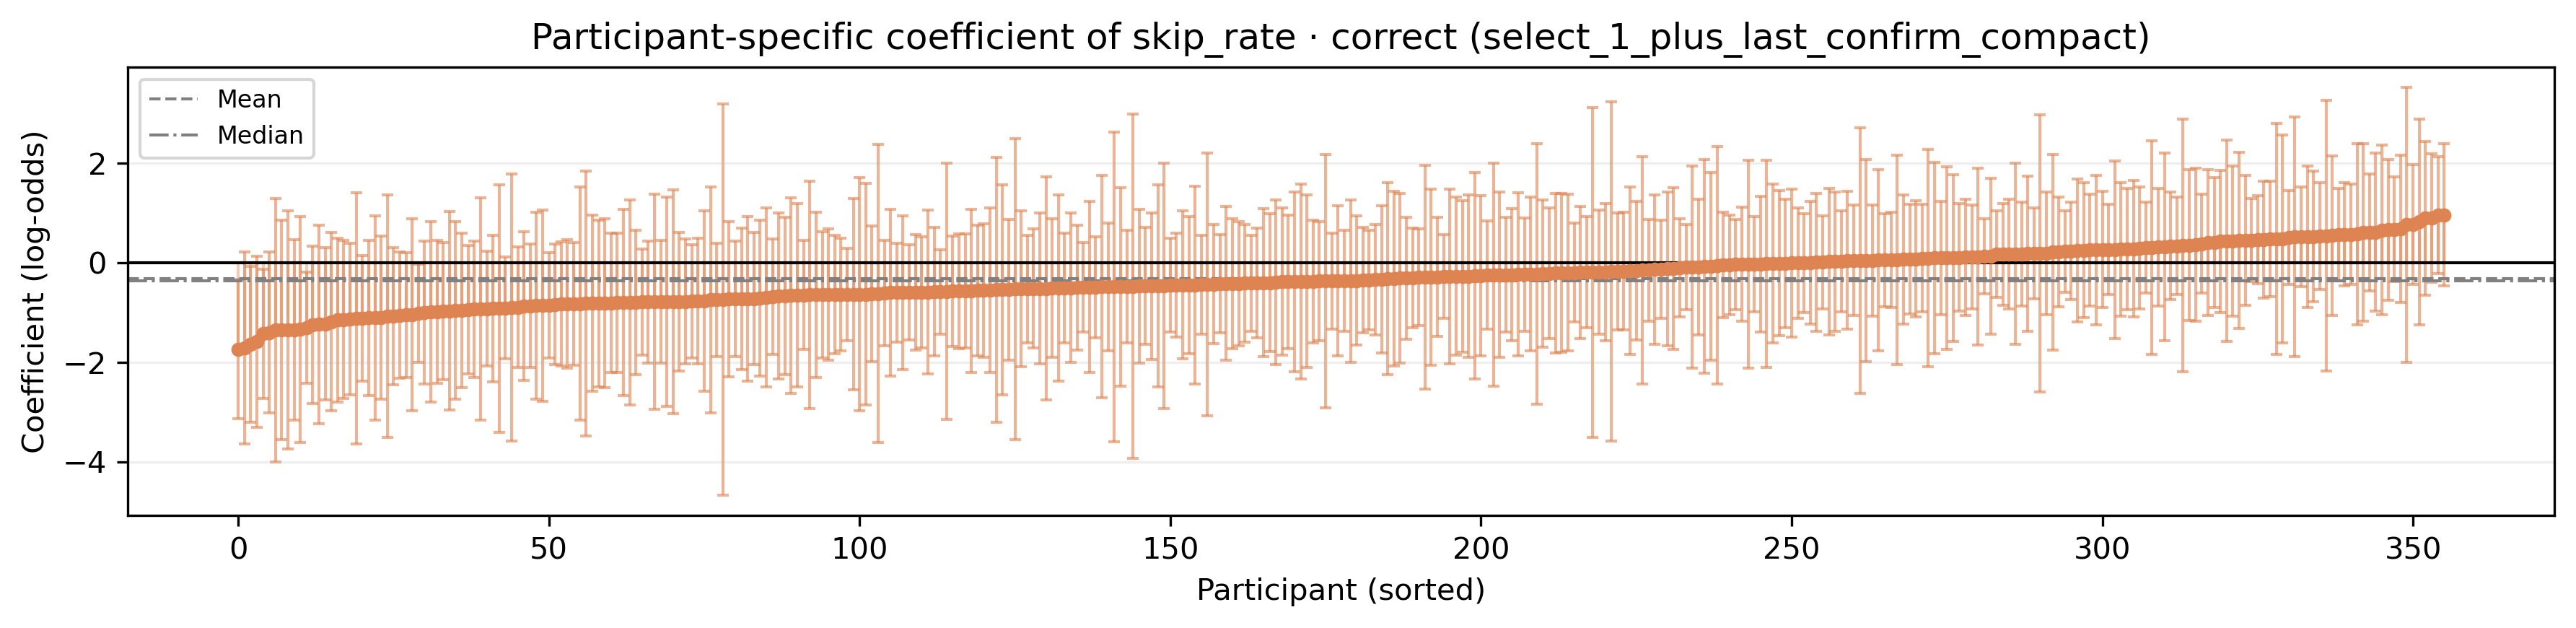

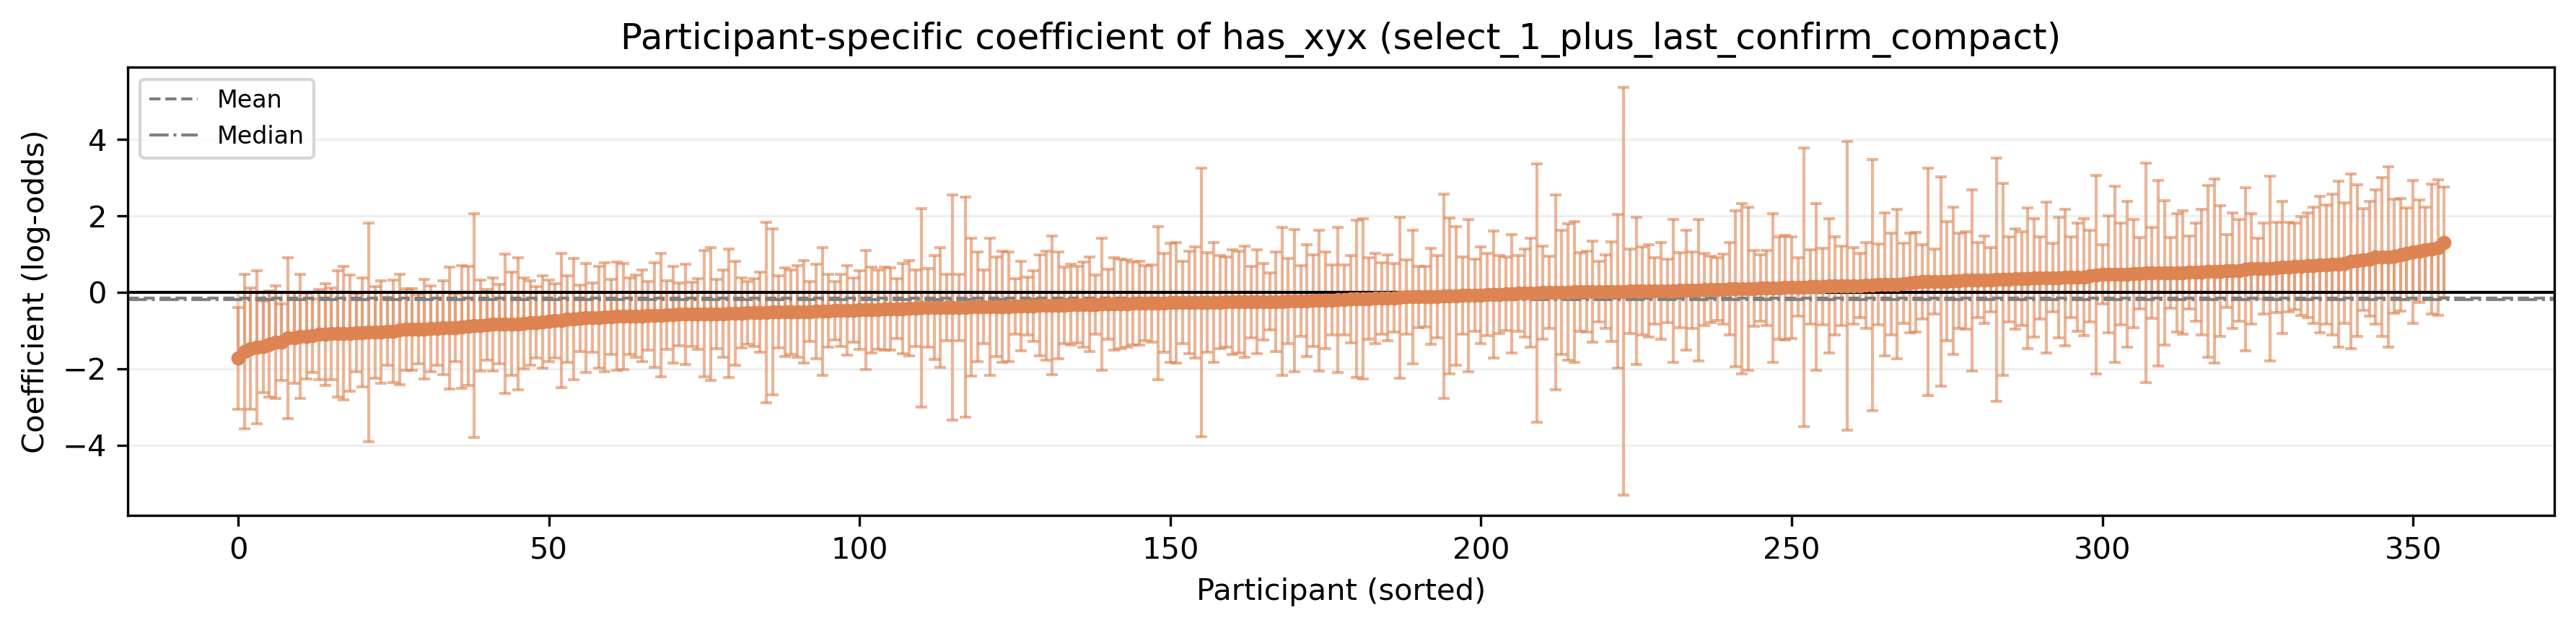

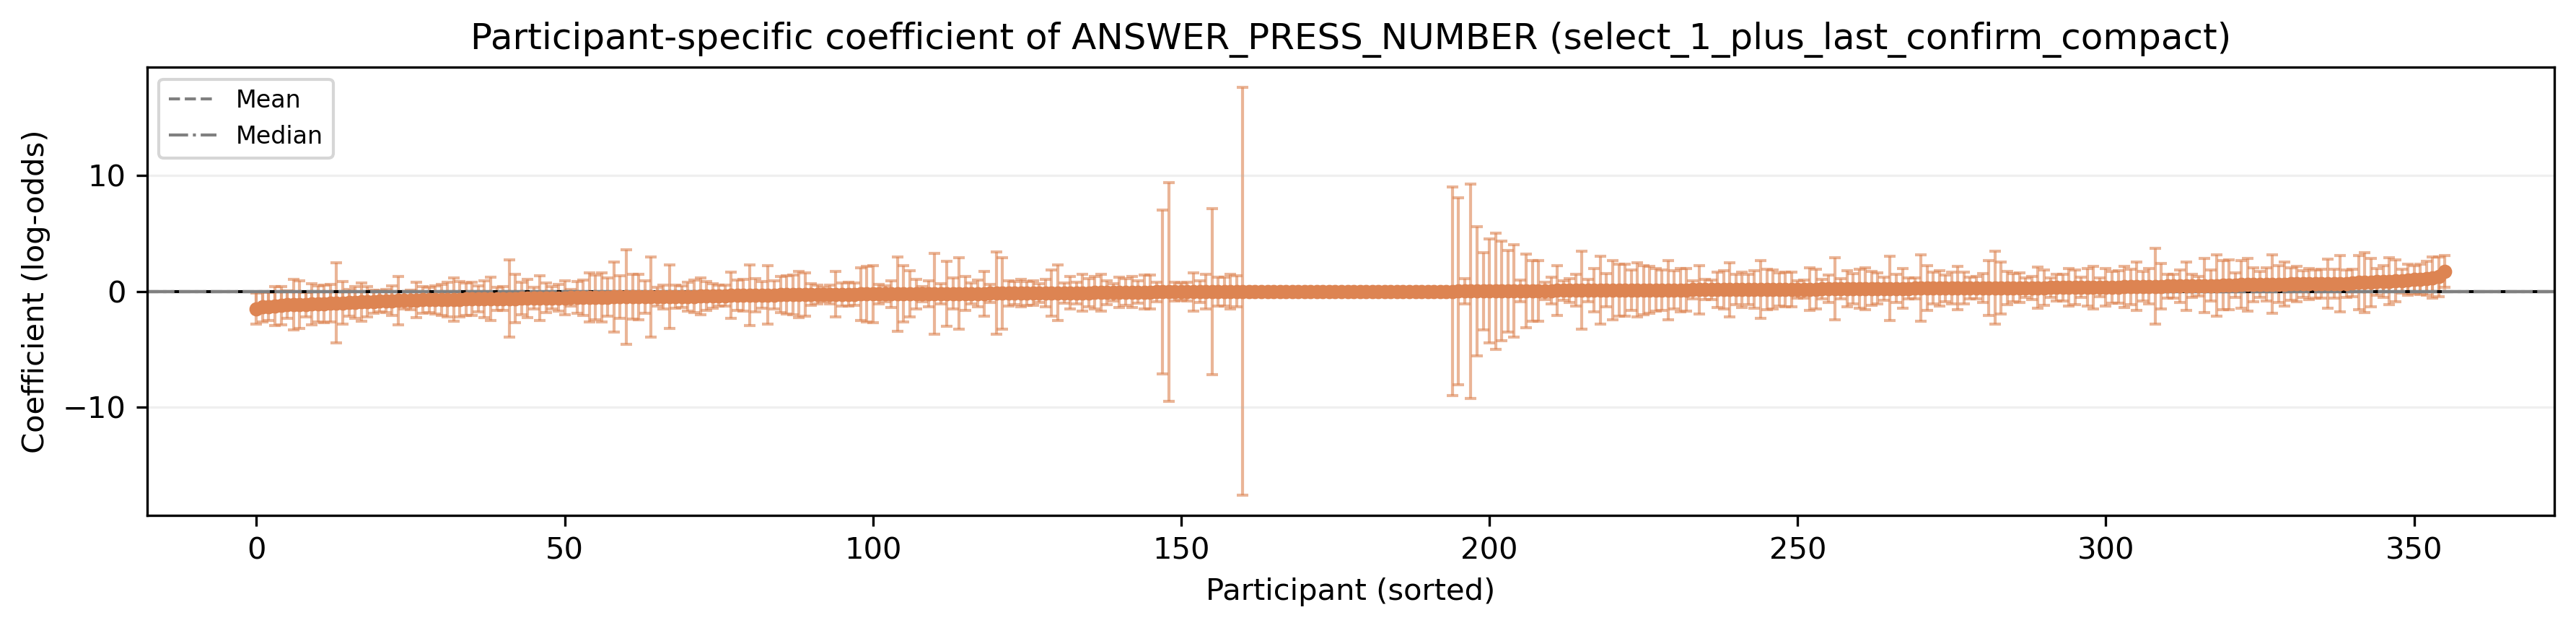

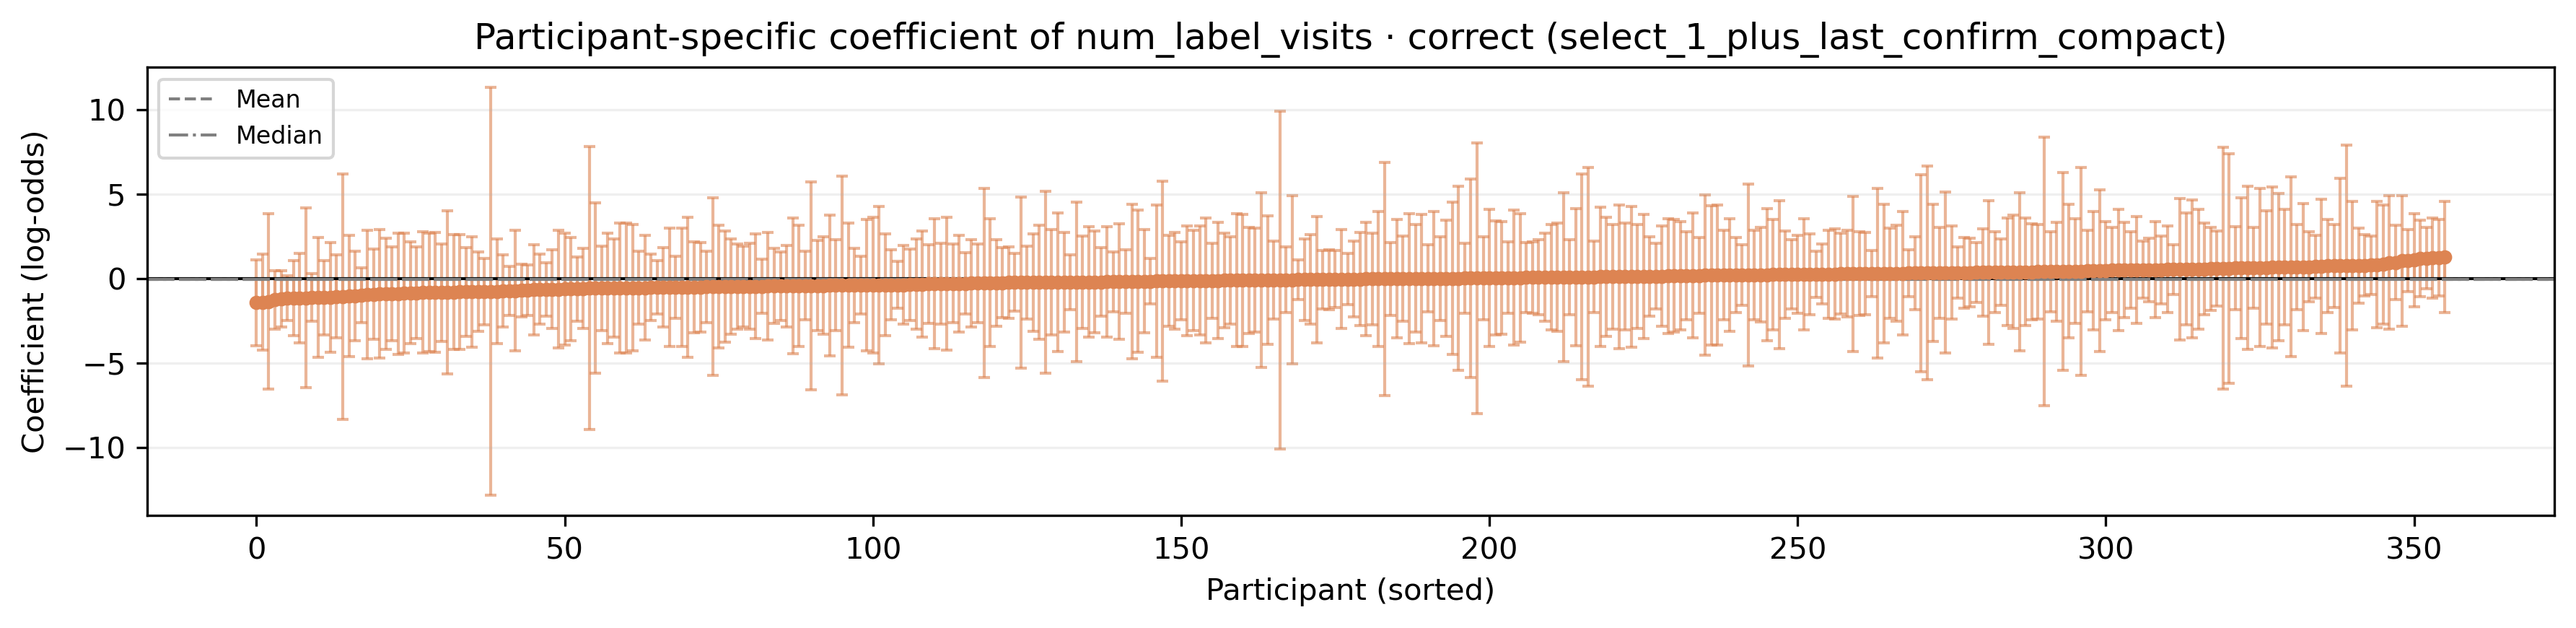

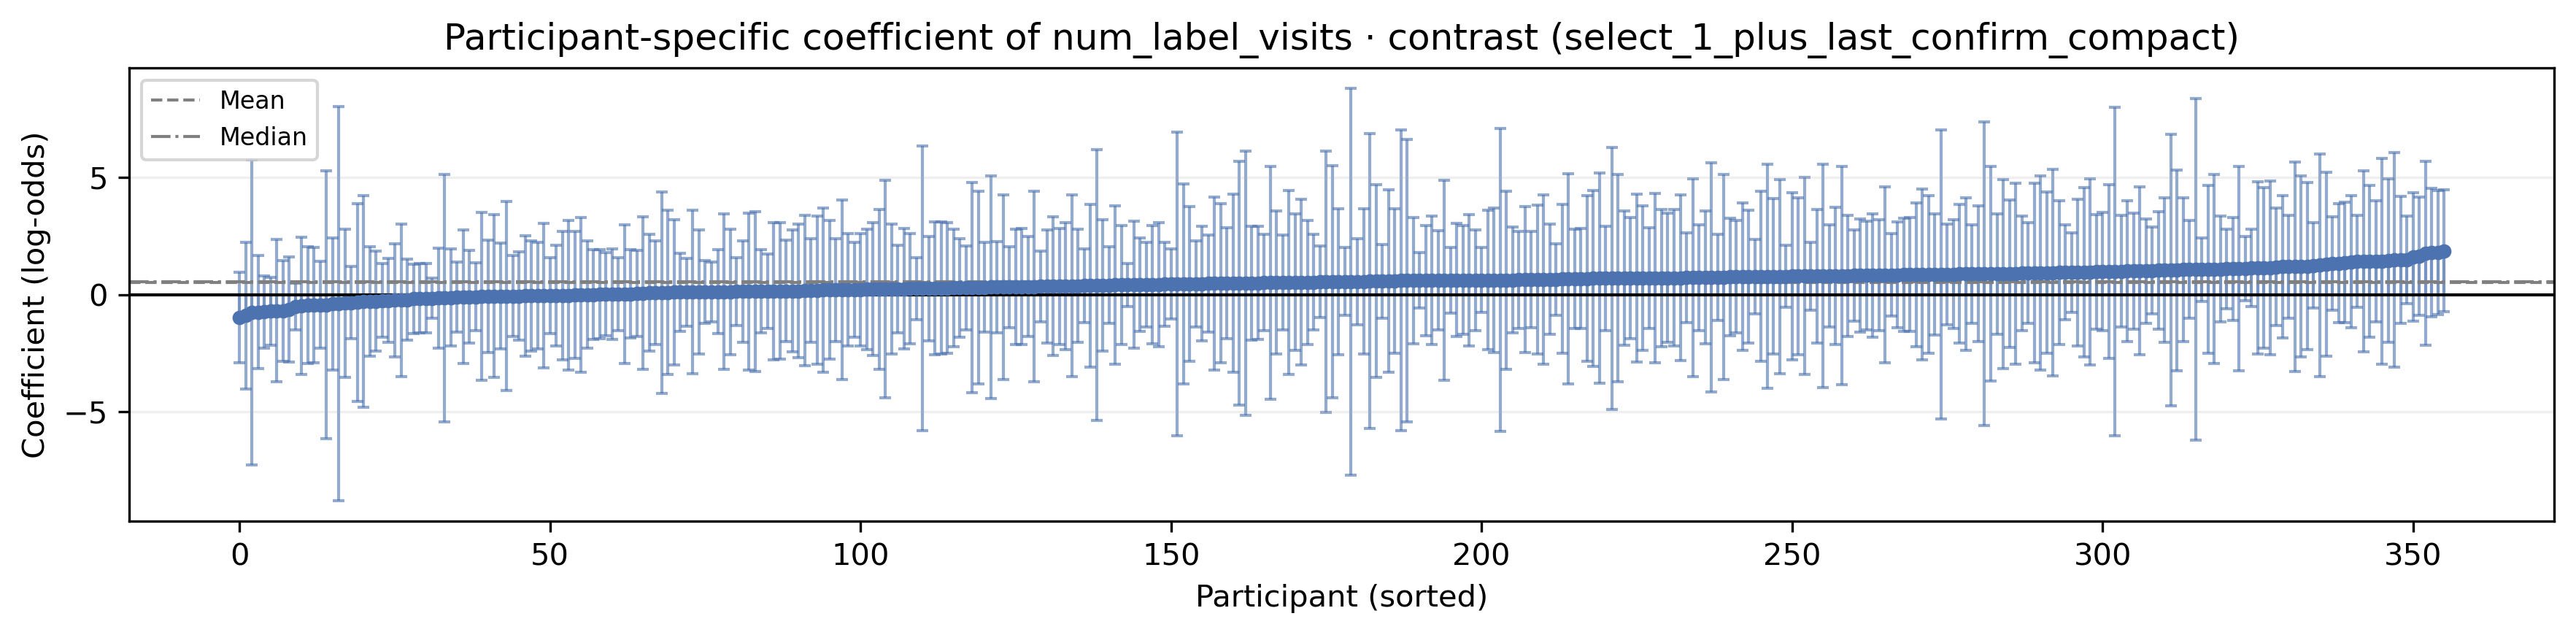

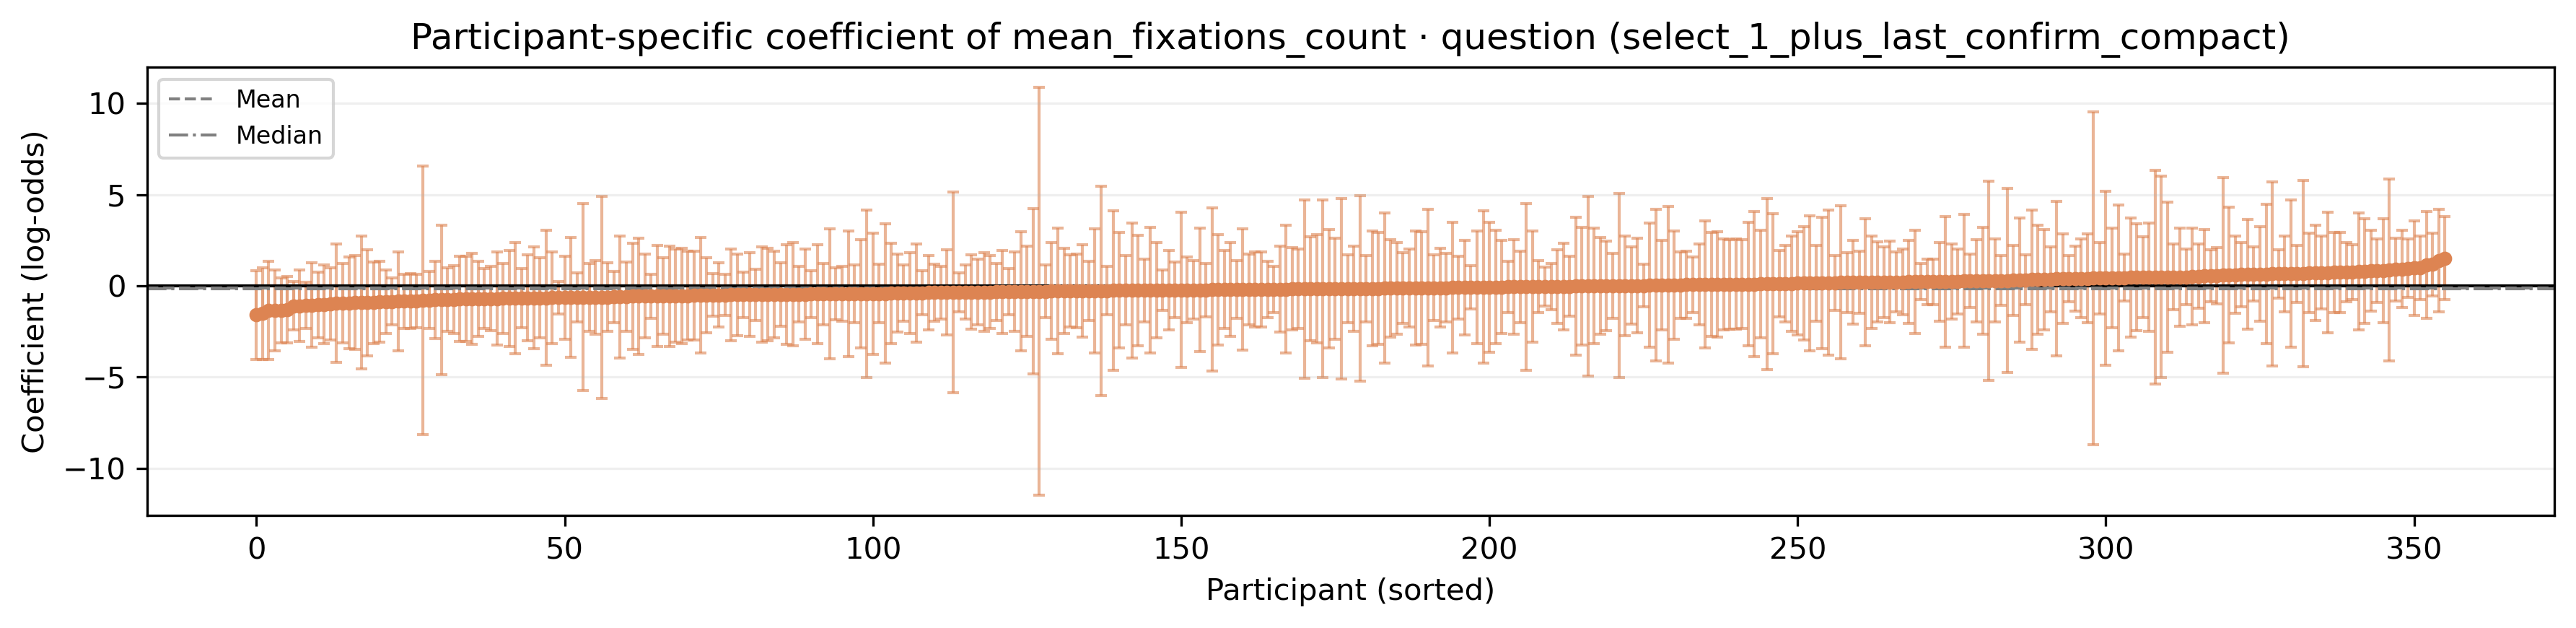

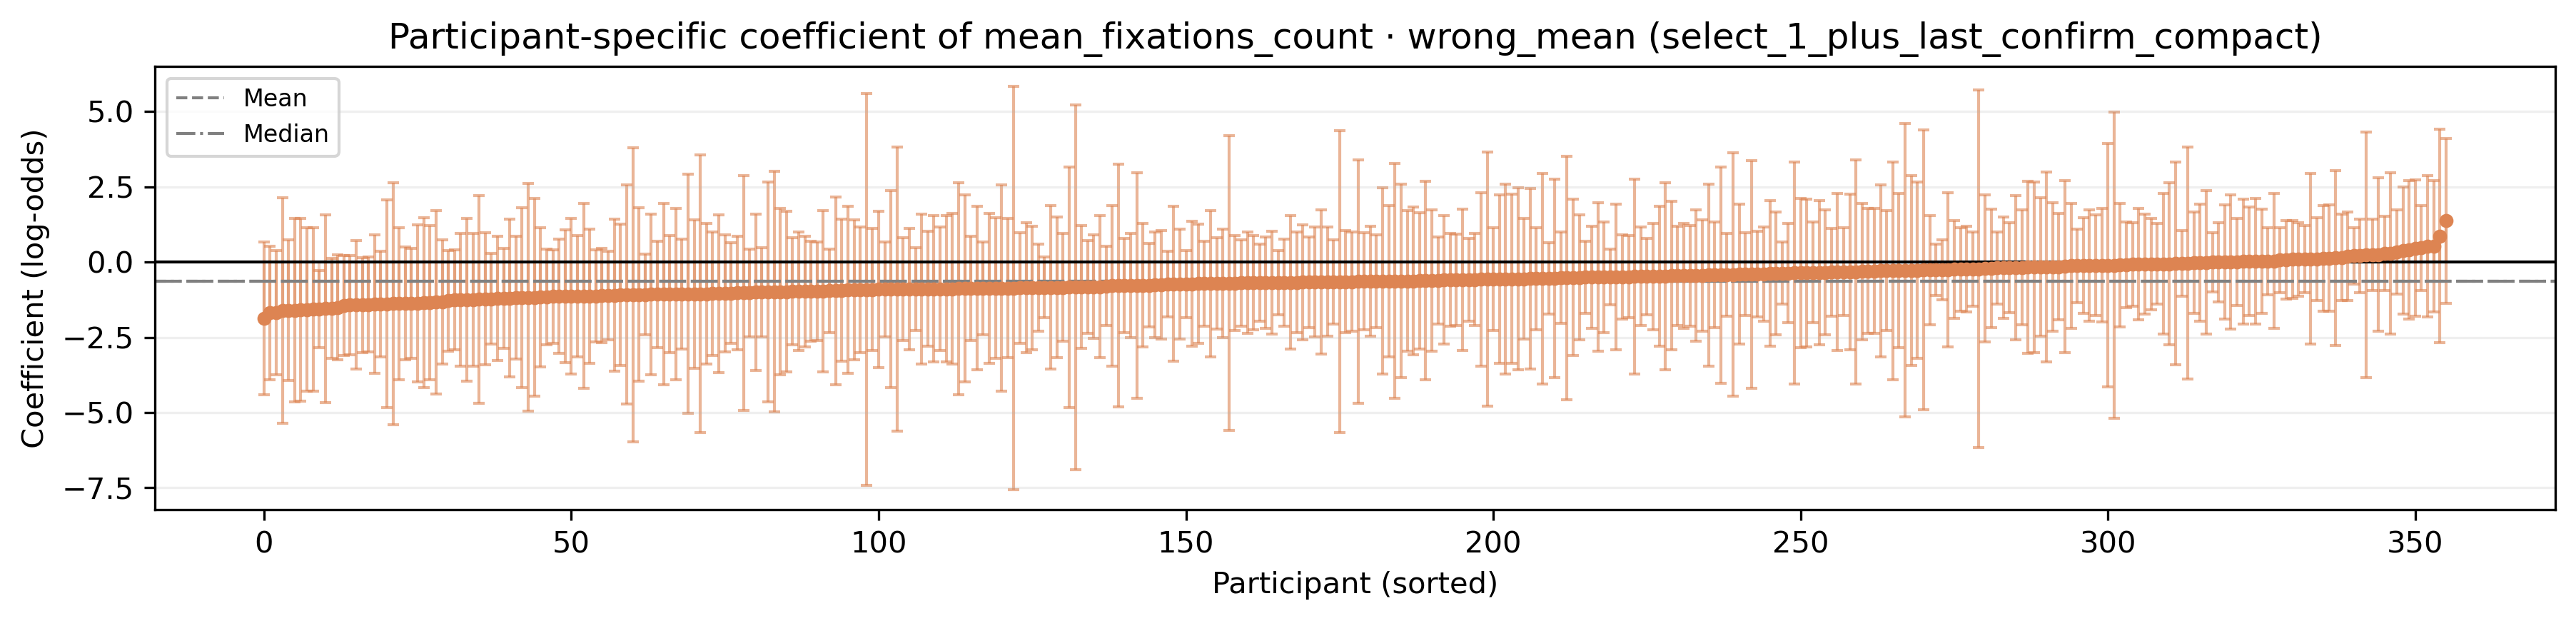

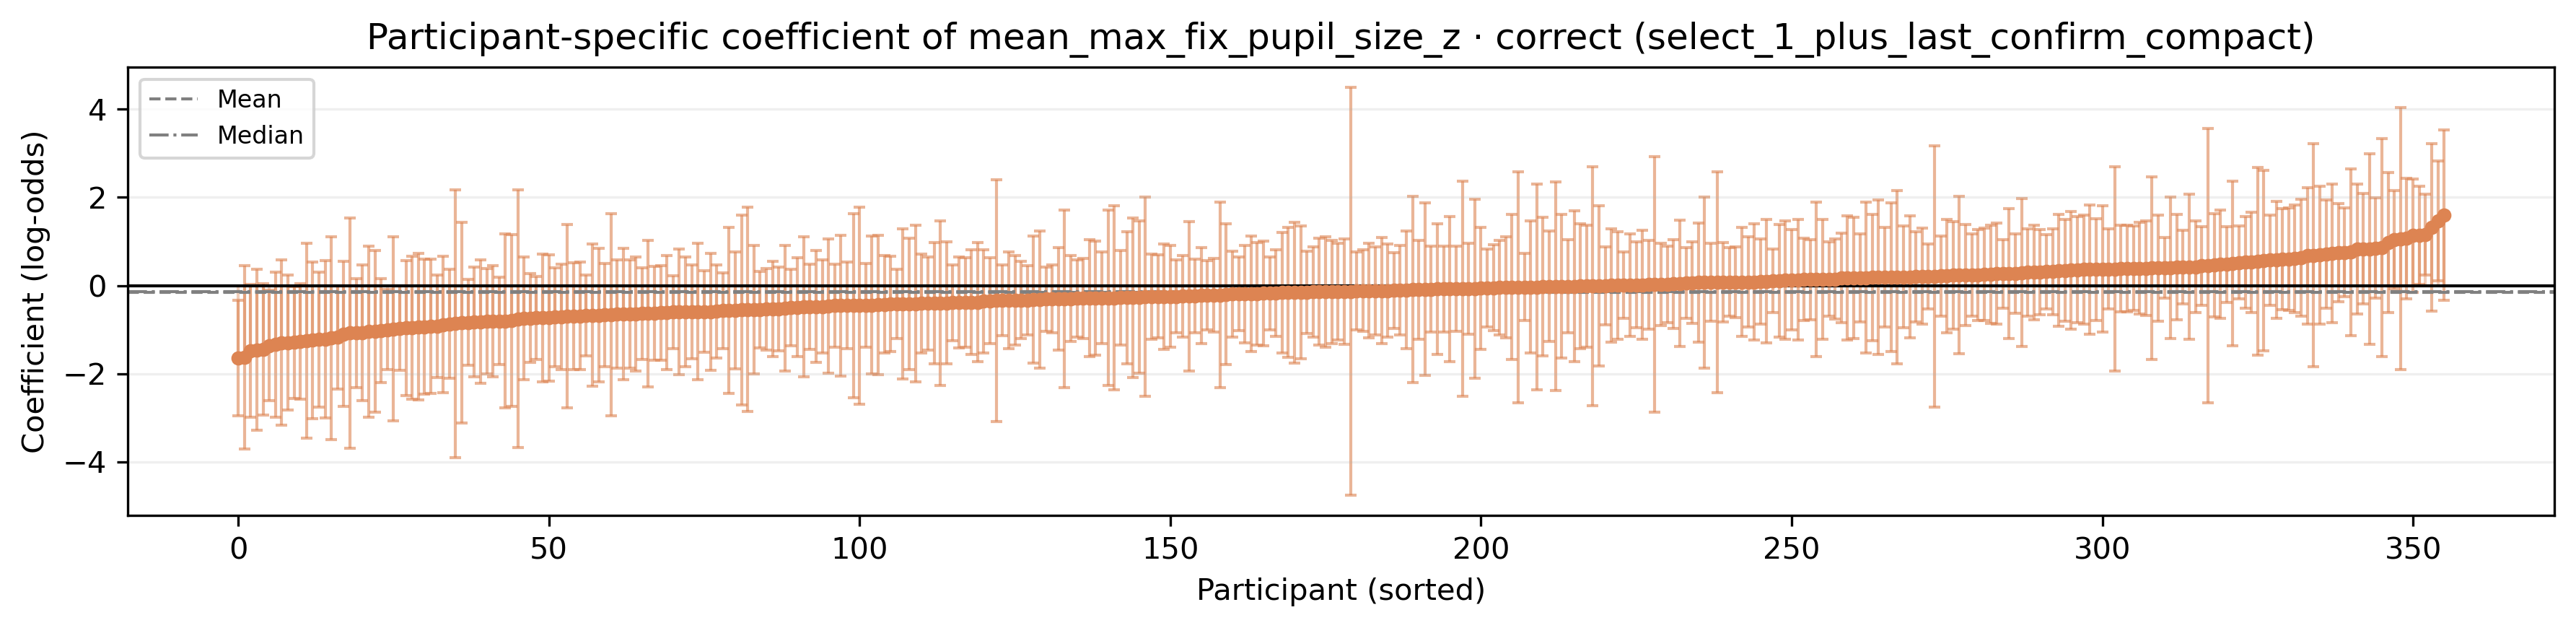

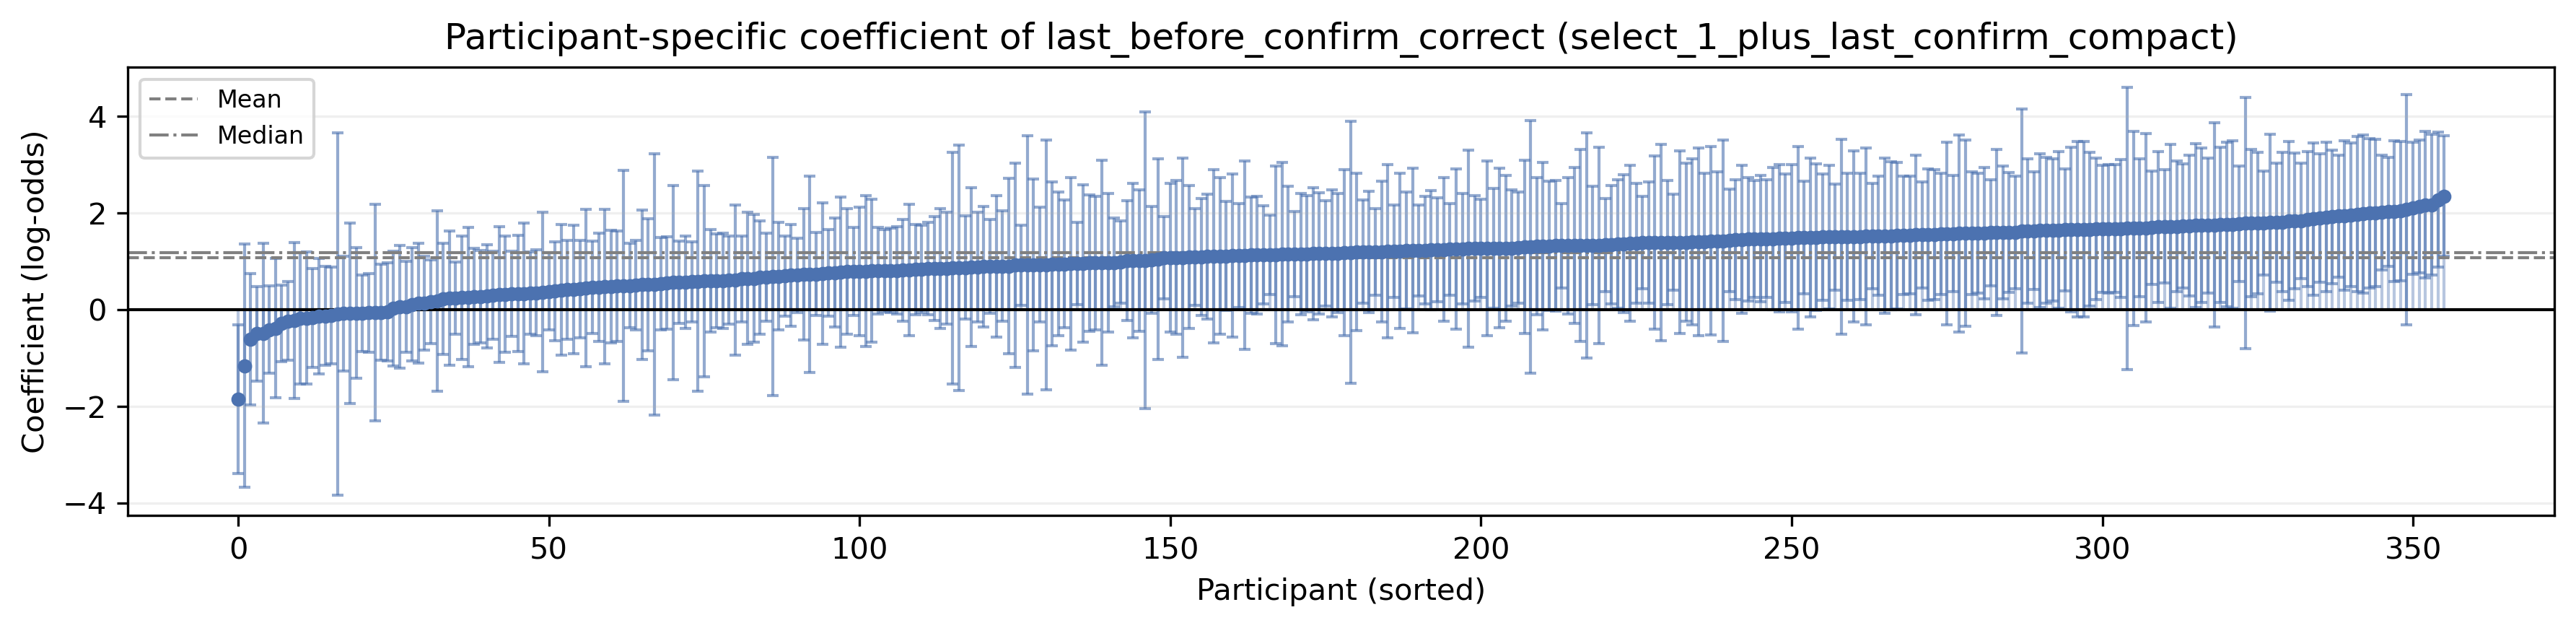

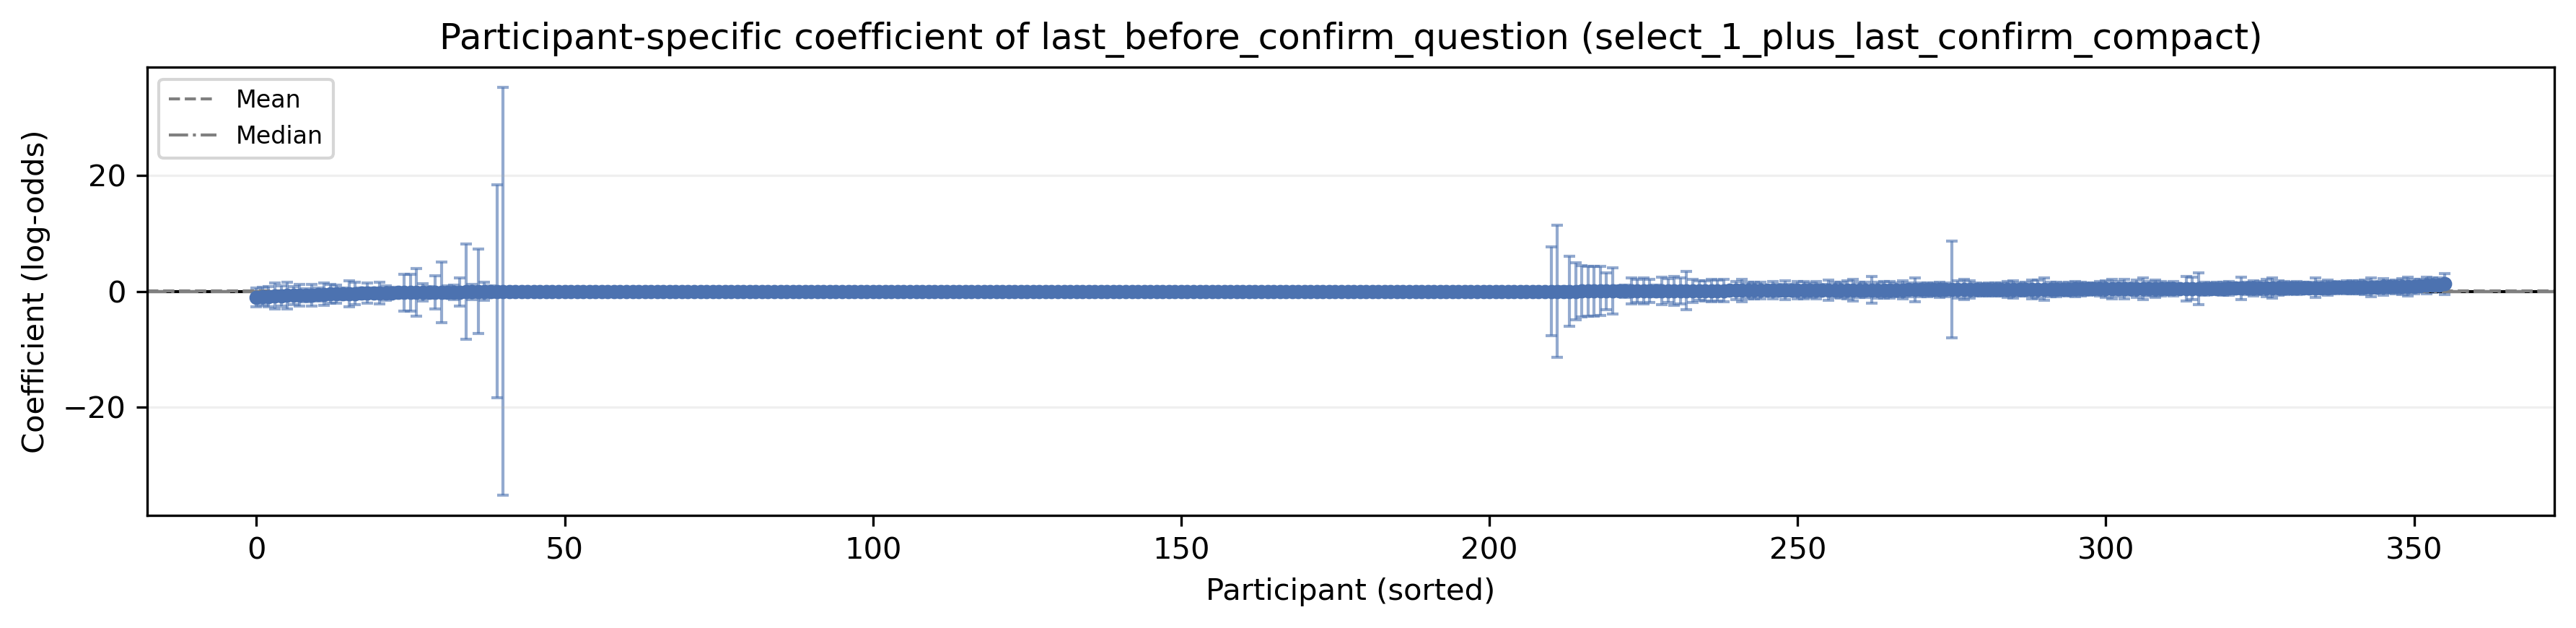

In [18]:
for feat in FEATURE_COLS:
    fig_pc, pc_df, _ = CC.plot_participant_coef_effect(
        results_by_pid, feat, feature_set_tag=FEATURE_SET_TAG,
    )